# Proyecto Integrador de Ciencia de Datos — **Fase 2**
## Análisis inferencial: contrastes de hipótesis sobre inasistencia escolar (EPHC 2022–2025)

| | |
|---|---|
| **Asignatura** | Data Science |
| **Fase** | 2 de 3 — Ponderación 25 % · **versión corregida tras la devolución** |
| **Integrantes** | Matías Morínigo · César Vielman · Iván Paredes |
| **Dataset** | `data/processed/dataset_fase1.parquet` — dataset limpio generado por la Fase 1 (24.316 adolescentes de 12 a 17 años) |
| **α declarado** | 0.05, fijado antes de ejecutar cualquier contraste |

**Cómo ejecutar.** Con los CSV de la EPHC en `data/raw/`, primero se corre `Fase1_DataScience_EPHC.ipynb`, que genera
el dataset limpio. Después, este notebook con `Kernel → Restart & Run All`. Todo lo que aparece abajo (tablas, figuras y
la tabla resumen) se calcula aquí: el notebook no lee resultados guardados previamente.

## 1. Pregunta, nivel de significancia y pruebas declaradas

**Pregunta (heredada de la Fase 1):** ¿En qué medida la zona y el departamento se asocian con la tasa de inasistencia
de adolescentes de 12 a 17 años, y qué motivos declaran los hogares, entre 2022 y 2025?

**α = 0.05**, declarado antes de ejecutar cualquier contraste.

**Inventario de pruebas.** Para no buscar significancia a fuerza de repetir pruebas, todas se declaran de antemano:

| Grupo | Pruebas | Cantidad | Control de error |
|---|---|:--:|---|
| Contrastes principales | H1, H2, H3, H4, H6 | 5 | Benjamini–Hochberg (familia principal) |
| Modelo de control | H5 (coeficiente rural) | 1 | Su propio p (ver §5). Sensibilidad: BH sobre las 6 |
| Post hoc de H3 | cada departamento vs Capital | 15 | Benjamini–Hochberg (familia propia) |
| Post hoc de H6 | residuos ajustados por motivo | 5 | Umbral de Bonferroni (|r| > 2.58) |
| Supuestos | Shapiro–Wilk (H1), LR de linealidad de la edad (H5) | 2 | Diagnósticos, no contrastes de la pregunta |
| Sensibilidad | EE / Wald agrupado por UPM en H1–H6, bootstrap por UPM, logit ponderado (H5), LR condicional (H6), Bonferroni de la familia principal | — | La decisión de la tabla usa el p ajustado por UPM |

Los residuos de H2 se usan solo para describir qué celda contribuye más al χ²; no son una prueba adicional.


## 2. Hipótesis formales

| N.° | H₀ (formal) | Hₐ (formal) | Lenguaje natural | Prueba |
|:--:|---|---|---|---|
| **H1** | p_rural ≤ p_urbana | p_rural > p_urbana | La inasistencia es mayor en el campo que en la ciudad | z de dos proporciones (unilateral) |
| **H2** | zona ⊥ motivo agrupado | zona y motivo asociados | El motivo declarado depende de la zona | χ² de independencia |
| **H3** | p_1 = … = p_16 (16 dptos.) | al menos un p_j distinto | Hay diferencias entre departamentos | χ² de homogeneidad + post hoc |
| **H4** | ρ(edad, no_asiste) ≤ 0 | ρ > 0 | La inasistencia aumenta con la edad | ρ de Spearman (unilateral) |
| **H5** | OR_rural = 1 (dados dpto., edad y sexo) | OR_rural ≠ 1 | La brecha rural persiste al controlar departamento, edad y sexo | Regresión logística múltiple |
| **H6** | período ⊥ motivo agrupado | período y motivo asociados | En 2025 cambia el peso relativo de los motivos | χ² de independencia + residuos |

**Familias del repertorio cubiertas:**
1. dos proporciones (H1);
2. asociación entre categóricas (H2 y H6);
3. tres o más grupos (H3);
4. significancia de una correlación (H4);
5. efecto controlando otras variables (H5);
6. IC por bootstrap (H1, y la V de Cramér en H2, H3 y H6).

## 3. Datos y supuestos generales

**Funciones auxiliares** (`src/fase2_helpers.py`). Se usan en varias pruebas, por eso están en un módulo:

| Función | Qué hace |
|---|---|
| `MOTIVO_GRUPO` | Agrupa los 16 motivos de la EPHC (ED10) en Económico, Familiar, Oferta, Personal y Otro |
| `cramers_v(tabla)` | V de Cramér = √(χ² / (n·(min(r,k)−1))): tamaño del efecto de un χ² |
| `cohen_h(p1, p2)` | h de Cohen = 2·arcsen√p1 − 2·arcsen√p2: tamaño del efecto de dos proporciones |
| `bootstrap_diff_proportions_cluster(...)` | IC percentil de p_a − p_b remuestreando conglomerados UPM (2000 réplicas, semilla fija) |
| `bootstrap_cramers_v_cluster(...)` | IC percentil de la V de Cramér remuestreando conglomerados UPM (1000 réplicas) |
| `spearman_ci(rho, n)` | IC de ρ por la transformación z de Fisher (EE de Bonett–Wright) |
| `chi2_supuestos(esperados)` | Regla de Cochran: mínimo esperado ≥ 1 y como mucho 20 % de celdas < 5 |
| `wald_cluster_asociacion(...)` | Wald de independencia con sándwich por UPM |
| `residuos_ajustados(tabla)` | Residuos de Haberman: (O−E)/√(E·(1−fila)·(1−col)), que siguen una N(0,1) bajo H₀ |
| `benjamini_hochberg(p)` | Corrección por comparaciones múltiples (control de la tasa de falsos descubrimientos) |


In [1]:
# ============================================================================
# Imports y configuración global (mismas convenciones que la Fase 1)
# ============================================================================
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import (proportions_ztest, confint_proportions_2indep,
                                          proportion_confint)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

SEMILLA = 42
ALPHA = 0.05          # declarado antes de ejecutar cualquier contraste
np.random.seed(SEMILLA)

RAIZ     = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DIR_PROC = RAIZ / 'data' / 'processed'
DIR_FIG  = RAIZ / 'output' / 'figuras'
DIR_TAB  = RAIZ / 'output' / 'tablas'
for _d in (DIR_PROC, DIR_FIG, DIR_TAB):
    _d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(RAIZ))
from src.fase2_helpers import (MOTIVO_GRUPO, cramers_v, cohen_h,
                               benjamini_hochberg, chi2_supuestos, residuos_ajustados,
                               spearman_ci, bootstrap_diff_proportions_cluster,
                               bootstrap_cramers_v_cluster, wald_cluster_asociacion)
from statsmodels.stats.multitest import multipletests

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 110, 'savefig.dpi': 200,
                     'savefig.bbox': 'tight', 'axes.titlesize': 13, 'axes.titleweight': 'bold',
                     'axes.labelsize': 11, 'font.size': 10, 'grid.color': '#e4e3df'})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
pd.set_option('display.max_colwidth', 90)

# Colores fijos por entidad (no por rango): urbana / 2022–2024 = azul; rural / 2025 = naranja
C_URB, C_RUR, C_GRIS = '#2a78d6', '#eb6834', '#52514e'

def guardar(fig, nombre):
    fig.savefig(DIR_FIG / f'{nombre}.png')
    plt.show()

def fmt_p(p):
    return '< 1e-300' if p == 0 else f'{p:.2e}'

print('Python:', sys.version.split()[0], '| pandas:', pd.__version__, '| statsmodels:', sm.__version__)
print('Raíz  :', RAIZ)


Python: 3.12.4 | pandas: 3.0.5 | statsmodels: 0.15.0
Raíz  : /Users/ivanparedesozuna/Developer/proyecto-ds-inasistencia-py


In [2]:
# ============================================================================
# Carga del dataset limpio generado por la Fase 1
# ============================================================================
candidatos = [DIR_PROC / 'dataset_fase1.parquet', RAIZ / 'output' / 'dataset_fase1.parquet',
              DIR_PROC / 'dataset_fase1.csv']
ruta = next((r for r in candidatos if r.exists() and r.stat().st_size > 0), None)
if ruta is None:
    raise FileNotFoundError(
        'No está el dataset limpio. Ejecutá primero notebooks/Fase1_DataScience_EPHC.ipynb.')
df = pd.read_parquet(ruta) if ruta.suffix == '.parquet' else pd.read_csv(ruta)
print('Dataset leído de:', ruta.relative_to(RAIZ))

# Variables derivadas para la inferencia
df['motivo_grupo'] = df['motivo_inasistencia'].map(MOTIVO_GRUPO)
df['periodo'] = np.where(df['anio_encuesta'] == 2025, '2025', '2022-2024')
df['rural'] = (df['zona'] == 'Rural').astype(int)
df['mujer'] = (df['sexo'] == 'Mujer').astype(int)
# Conglomerados: la UPM se repite entre años (panel rotativo), por eso se agrupa por UPM sola,
# que es la opción más conservadora. El hogar sí se identifica dentro de cada año.
df['upm_id'] = df['UPM']
df['hogar_id'] = (df['anio_encuesta'].astype(str) + '-' + df['UPM'].astype(str) + '-'
                  + df['NVIVI'].astype(str) + '-' + df['NHOGA'].astype(str))

cols_modelo = ['no_asiste', 'rural', 'edad', 'mujer', 'departamento', 'zona', 'upm_id', 'factor_expansion']
assert df[cols_modelo].isna().sum().sum() == 0, 'Hay faltantes en variables del modelo'
sin_motivo = int(((df.no_asiste == 1) & df.motivo_grupo.isna()).sum())

print(f'Filas: {len(df):,}  ·  años: {sorted(df.anio_encuesta.unique())}  ·  departamentos: {df.departamento.nunique()}')
print(f'No asisten: {int(df.no_asiste.sum()):,}  ·  de ellos sin motivo agrupable: {sin_motivo}')
df.head(3)


Dataset leído de: output/dataset_fase1.parquet


Filas: 24,316  ·  años: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]  ·  departamentos: 16
No asisten: 1,912  ·  de ellos sin motivo agrupable: 0


,anio_encuesta,UPM,NVIVI,NHOGA,L02,edad,sexo,zona,departamento,sector,asiste_actualmente,no_asiste,motivo_inasistencia,factor_expansion,motivo_grupo,periodo,rural,mujer,upm_id,hogar_id
0,2022,14,22,1,4,13,Mujer,Urbana,Capital,Oficial,1,0,NaN,89.143495,NaN,2022-2024,0,1,14,2022-14-22-1
1,2022,14,24,1,4,17,Hombre,Urbana,Capital,Oficial,1,0,NaN,89.143495,NaN,2022-2024,0,0,14,2022-14-24-1
2,2022,14,24,1,5,17,Hombre,Urbana,Capital,Oficial,1,0,NaN,89.143495,NaN,2022-2024,0,0,14,2022-14-24-1


### 3.1 Nota de ponderación: por qué las cifras difieren de la Fase 1

La Fase 1 describe a la **población** y por eso pondera cada persona por su factor de expansión (FEX). Las pruebas de
`scipy` y `statsmodels` que usamos suponen un muestreo aleatorio simple de **personas de la muestra**, así que aquí la
inferencia se hace sobre el **n muestral sin ponderar**. Si se ponderara un χ² o una z “a mano”, se inflaría n a millones
de personas y los p-valores no tendrían sentido. La sensibilidad de H5 estima el modelo ponderado para comprobar que la
conclusión no depende de esta decisión.

In [3]:
# ============================================================================
# Nota de ponderación: Fase 1 (ponderada) vs Fase 2 (muestral, sin ponderar)
# ============================================================================
def tasa_pond(g):
    return 100 * np.average(g['no_asiste'], weights=g['factor_expansion'])

grupos = {'Nacional': df, 'Rural': df[df.zona == 'Rural'], 'Urbana': df[df.zona == 'Urbana']}
comp_pond = pd.DataFrame({
    'n muestral': {k: len(g) for k, g in grupos.items()},
    'tasa sin ponderar % (Fase 2)': {k: 100 * g.no_asiste.mean() for k, g in grupos.items()},
    'tasa ponderada % (Fase 1)': {k: tasa_pond(g) for k, g in grupos.items()},
}).round(2)
comp_pond['diferencia (pp)'] = (comp_pond.iloc[:, 1] - comp_pond.iloc[:, 2]).round(2)
TASA_NAC_SP = comp_pond.loc['Nacional', 'tasa sin ponderar % (Fase 2)']
TASA_NAC_P = comp_pond.loc['Nacional', 'tasa ponderada % (Fase 1)']
display(comp_pond)

,n muestral,tasa sin ponderar % (Fase 2),tasa ponderada % (Fase 1),diferencia (pp)
Nacional,24316,7.86,7.44,0.42
Rural,11242,11.30,11.43,-0.13
Urbana,13074,4.91,4.88,0.03


La tasa nacional muestral es **7.86 %**, frente a **7.44 %** ponderada. La diferencia (0.42 pp) se debe a que la
muestra tiene relativamente más adolescentes rurales que la población. Dentro de cada zona, las tasas ponderadas y sin
ponderar casi coinciden (Rural 11.30 % vs 11.43 %; Urbana 4.91 % vs 4.88 %). **Todas las cifras de esta fase son
muestrales, sin ponderar**, salvo que se indique lo contrario.

### 3.2 Qué supuestos aplican aquí, y por qué no Shapiro, Levene ni Q-Q sobre los datos

Shapiro–Wilk y el gráfico Q-Q comprueban que una **variable continua** sea normal, y Levene compara **varianzas** de una
variable continua entre grupos. Son supuestos de la t de Student y del ANOVA, que comparan medias. En este proyecto el
desenlace `no_asiste` es **binario (0/1)** y los predictores (zona, departamento, motivo, período) son **categóricos**:

- una variable 0/1 nunca es normal, y Shapiro la rechazaría siempre sin aportar información;
- la varianza de una proporción queda fijada por p (p·(1−p)), así que no hay varianzas libres que comparar con Levene;
- por eso usamos pruebas de proporciones, χ², Spearman y regresión logística, cuyos supuestos son otros.

| Prueba | Supuesto que se verifica | Cómo |
|---|---|---|
| z de proporciones (H1) | Aproximación normal del estimador | n·p ≥ 10 y n·(1−p) ≥ 10 en cada grupo; **Shapiro y Q-Q sobre la distribución bootstrap de Δp**, que sí es continua |
| χ² (H2, H3, H6) | Frecuencias esperadas suficientes | Regla de Cochran: mínimo esperado ≥ 1 y como mucho 20 % de celdas < 5 |
| Spearman (H4) | Escala al menos ordinal y relación monótona | Tasa por edad estrictamente creciente |
| Logística (H5) | EPV ≥ 10, sin separación, sin multicolinealidad, edad lineal en el logit | Conteo de eventos, VIF, LR lineal vs categórica |
| Todas | Independencia de las observaciones | §3.3 y sensibilidad con EE agrupados por UPM |

### 3.3 Independencia de las observaciones

La EPHC es una muestra por **conglomerados**: se sortean UPM (áreas) y dentro de ellas viviendas. Además, en un mismo
hogar puede haber varios adolescentes hermanos, y las UPM se repiten entre años porque el panel es rotativo. Las
observaciones no son independientes. Lo medimos con la correlación intraclase (ICC) y el efecto de diseño
aproximado, deff ≈ 1 + (m̄ − 1)·ICC.

In [4]:
# ============================================================================
# Estructura de dependencia: hogares y UPM (conglomerados del diseño EPHC)
# ============================================================================
def icc_anova(y: pd.Series, grupo: pd.Series) -> float:
    """Correlación intraclase por ANOVA de un factor (estimador clásico para tamaños desiguales)."""
    d = pd.DataFrame({'y': y.to_numpy(), 'g': grupo.to_numpy()})
    k = d.groupby('g')['y'].size()
    m = d.groupby('g')['y'].mean()
    N, a = k.sum(), len(k)
    ssb = (k * (m - d.y.mean()) ** 2).sum()
    ssw = ((d.y - d.g.map(m)) ** 2).sum()
    msb, msw = ssb / (a - 1), ssw / (N - a)
    n0 = (N - (k ** 2).sum() / N) / (a - 1)
    return float((msb - msw) / (msb + (n0 - 1) * msw))

filas = []
for nombre, col in [('Hogar (año×UPM×vivienda×hogar)', 'hogar_id'), ('UPM (todas las rondas)', 'upm_id')]:
    tam = df.groupby(col).size()
    icc = icc_anova(df['no_asiste'], df[col])
    deff = 1 + (tam.mean() - 1) * icc
    filas.append({'conglomerado': nombre, 'n conglomerados': len(tam),
                  'adolescentes por conglomerado (media)': round(tam.mean(), 2),
                  '% en conglomerado con >1 adolescente': round(100 * (df[col].map(tam) > 1).mean(), 1),
                  'ICC no_asiste': round(icc, 3), 'efecto de diseño aprox.': round(deff, 2),
                  'n efectivo aprox.': int(len(df) / deff)})
dependencia = pd.DataFrame(filas).set_index('conglomerado')
DEFF_UPM = dependencia.loc['UPM (todas las rondas)', 'efecto de diseño aprox.']
display(dependencia)

,n conglomerados,adolescentes por conglomerado (media),% en conglomerado con >1 adolescente,ICC no_asiste,efecto de diseño aprox.,n efectivo aprox.
conglomerado,,,,,,
Hogar (año×UPM×vivienda×hogar),19370,1.26,37.7,0.232,1.06,22954
UPM (todas las rondas),1817,13.38,99.9,0.108,2.34,10380


El 37.7 % de los adolescentes comparte hogar con otro adolescente de la muestra, y dentro del hogar la correlación es
alta (ICC 0.23). Como los hogares son chicos (1.26 adolescentes en promedio), el efecto de diseño por hogar es pequeño
(1.06). El nivel que más pesa es la **UPM**: ICC 0.11 con unos 13 adolescentes por UPM, es decir, **deff ≈ 2.3**. Los
24.316 casos equivalen a unos **10.400 independientes**. Los errores estándar ingenuos están subestimados en un factor
de alrededor de √2.3 ≈ 1.5, y por eso los p-valores ingenuos son extremos (10⁻²⁵⁶).
El ajuste por UPM (errores estándar agrupados, Wald por conglomerado o bootstrap de UPM) se aplica en **H1, H2, H3, H4,
H5, H6 y en el post hoc de H3**. La tabla resumen decide con esos p, no con los p que suponen independencia.


## 4. Contrastes

### H1 — Zona rural vs urbana (z de dos proporciones)

**Justificación de la prueba.** El desenlace es binario y hay **dos grupos independientes** (rural y urbano), así que se
comparan dos proporciones. La H₁ es direccional (la Fase 1 mostró una tasa rural mayor), por eso la prueba es unilateral.
Con n de miles por grupo, la z de proporciones es adecuada si se cumple n·p ≥ 10; la exacta de Fisher solo haría falta
con conteos chicos. El IC bootstrap cumple el requisito 6.3 y no supone normalidad.

**Supuestos (antes de la prueba):**

In [5]:
# H1 — Verificación de supuestos ANTES de la prueba
rural = df.loc[df.zona == 'Rural', 'no_asiste'].to_numpy()
urbana = df.loc[df.zona == 'Urbana', 'no_asiste'].to_numpy()
count = np.array([rural.sum(), urbana.sum()])
nobs = np.array([len(rural), len(urbana)])
p_pool = count.sum() / nobs.sum()

sup_h1 = pd.DataFrame({
    'n': nobs,
    'n·p (eventos)': count,
    'n·(1−p)': nobs - count,
    'n·p̂_pool (bajo H0)': (nobs * p_pool).round(1),
    'n·(1−p̂_pool)': (nobs * (1 - p_pool)).round(1),
}, index=['Rural', 'Urbana'])
sup_h1['cumple ≥ 10'] = sup_h1.drop(columns='n').min(axis=1) >= 10
display(sup_h1)
print('Aproximación normal válida en ambos grupos:', bool(sup_h1['cumple ≥ 10'].all()))

,n,n·p (eventos),n·(1−p),n·p̂_pool (bajo H0),n·(1−p̂_pool),cumple ≥ 10
Rural,11242,1270,9972,884.0,10358.0,True
Urbana,13074,642,12432,1028.0,12046.0,True


Aproximación normal válida en ambos grupos: True


Todas las celdas superan ampliamente 10: el mínimo es 642 eventos urbanos. La aproximación normal es válida.

In [6]:
# H1 — Prueba z de proporciones (unilateral), IC Wald, IC bootstrap y tamaños de efecto
z_h1, p_h1 = proportions_ztest(count, nobs, alternative='larger')
p_r, p_u = rural.mean(), urbana.mean()
ci_wald = confint_proportions_2indep(count[0], nobs[0], count[1], nobs[1], compare='diff', method='wald')
# Bootstrap por UPM (conglomerado del diseño), no por persona
boot_mean, boot_lo, boot_hi, boot_dist = bootstrap_diff_proportions_cluster(
    df, 'no_asiste', 'zona', 'upm_id', 'Rural', 'Urbana', seed=SEMILLA, return_dist=True)
h_h1 = cohen_h(p_r, p_u)
rr_h1 = p_r / p_u
ci_rr = confint_proportions_2indep(count[0], nobs[0], count[1], nobs[1], compare='ratio', method='log')

print(f'p_rural = {p_r:.4f}   p_urbana = {p_u:.4f}   Δp = {p_r - p_u:.4f}')
print(f'z = {z_h1:.3f}   p (unilateral) = {fmt_p(p_h1)}')
print(f'IC 95% Wald de Δp      : [{ci_wald[0]:.4f}, {ci_wald[1]:.4f}]')
print(f'IC 95% bootstrap por UPM de Δp : [{boot_lo:.4f}, {boot_hi:.4f}]   (2000 réplicas de conglomerados, semilla {SEMILLA})')
print(f'h de Cohen = {h_h1:.3f}  →  umbrales de Cohen: 0.2 pequeño · 0.5 mediano · 0.8 grande')
print(f'Razón de tasas (RR) = {rr_h1:.2f}   IC 95% [{ci_rr[0]:.2f}, {ci_rr[1]:.2f}]')


p_rural = 0.1130   p_urbana = 0.0491   Δp = 0.0639
z = 18.447   p (unilateral) = 2.76e-76
IC 95% Wald de Δp      : [0.0569, 0.0708]
IC 95% bootstrap por UPM de Δp : [0.0514, 0.0757]   (2000 réplicas de conglomerados, semilla 42)
h de Cohen = 0.239  →  umbrales de Cohen: 0.2 pequeño · 0.5 mediano · 0.8 grande
Razón de tasas (RR) = 2.30   IC 95% [2.10, 2.52]


Shapiro–Wilk sobre las 2000 réplicas del bootstrap por UPM de Δp: W = 0.9993, p = 0.676


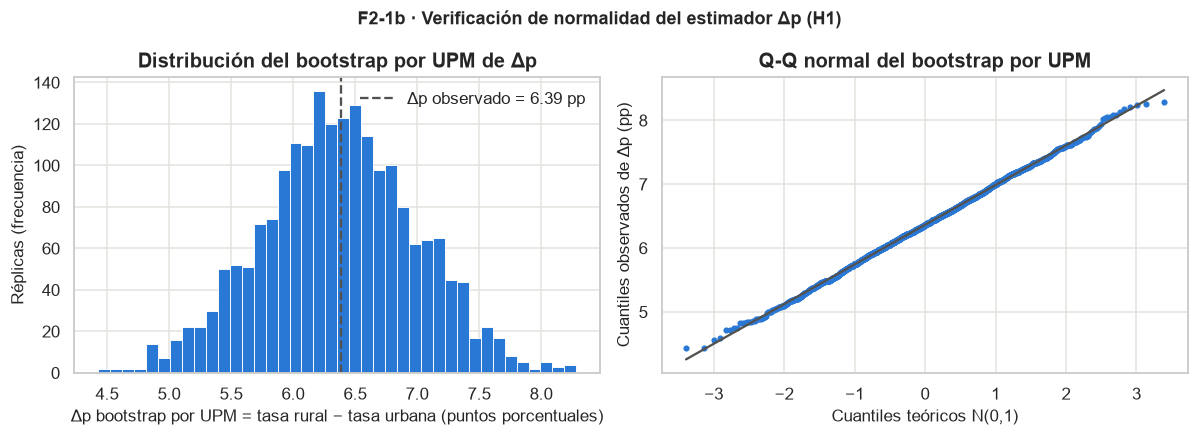

In [7]:
# H1 — ¿La distribución muestral de Δp es aproximadamente normal? (aquí sí aplican Shapiro y Q-Q)
sw_stat, sw_p = stats.shapiro(boot_dist)
print(f'Shapiro–Wilk sobre las 2000 réplicas del bootstrap por UPM de Δp: W = {sw_stat:.4f}, p = {sw_p:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(boot_dist * 100, bins=40, color=C_URB, edgecolor='white', linewidth=0.6)
axes[0].axvline((p_r - p_u) * 100, color=C_GRIS, ls='--', lw=1.5, label=f'Δp observado = {(p_r - p_u)*100:.2f} pp')
axes[0].set_xlabel('Δp bootstrap por UPM = tasa rural − tasa urbana (puntos porcentuales)')
axes[0].set_ylabel('Réplicas (frecuencia)')
axes[0].set_title('Distribución del bootstrap por UPM de Δp')
axes[0].legend(frameon=False)
stats.probplot(boot_dist * 100, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set(markerfacecolor=C_URB, markeredgecolor=C_URB, markersize=3)
axes[1].get_lines()[1].set(color=C_GRIS, lw=1.5)
axes[1].set_title('Q-Q normal del bootstrap por UPM')
axes[1].set_xlabel('Cuantiles teóricos N(0,1)')
axes[1].set_ylabel('Cuantiles observados de Δp (pp)')
fig.suptitle('F2-1b · Verificación de normalidad del estimador Δp (H1)', fontweight='bold')
fig.tight_layout()
guardar(fig, 'F2_1b_qq_bootstrap')


**Interpretación de F2-1b.** Las 2000 réplicas del bootstrap **por UPM** de Δp forman una campana simétrica centrada
cerca del valor observado (6.39 pp), y en el Q-Q los puntos siguen la recta salvo las réplicas más extremas.
Shapiro–Wilk no rechaza la normalidad (W ≈ 0.999, p ≈ 0.68). Eso es **compatible con una aproximación normal** del
estimador; no demuestra que la distribución sea normal. El intervalo que se usa para decidir es el del bootstrap por
conglomerados, que no necesita ese supuesto.


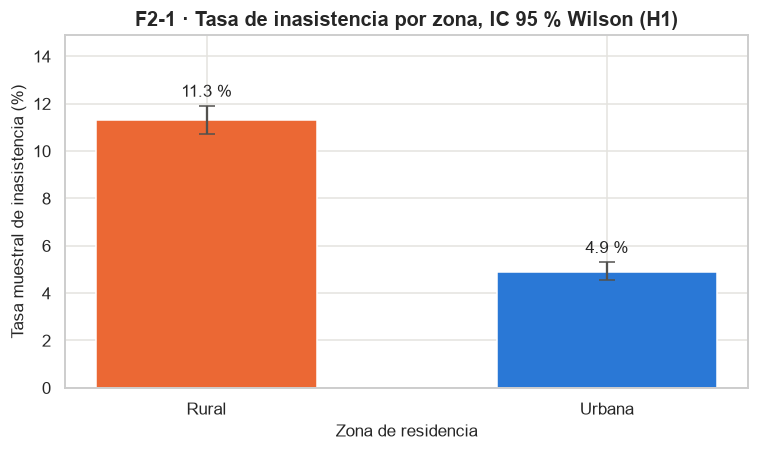

In [8]:
# F2-1 — Tasa muestral por zona con IC 95% de Wilson
tasas_zona = pd.DataFrame({'n': nobs, 'eventos': count}, index=['Rural', 'Urbana'])
tasas_zona['tasa'] = tasas_zona.eventos / tasas_zona.n
lo, hi = proportion_confint(tasas_zona.eventos, tasas_zona.n, alpha=ALPHA, method='wilson')
tasas_zona['ic_lo'], tasas_zona['ic_hi'] = lo, hi

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(2)
ax.bar(x, tasas_zona.tasa * 100, width=0.55, color=[C_RUR, C_URB])
ax.errorbar(x, tasas_zona.tasa * 100,
            yerr=[(tasas_zona.tasa - tasas_zona.ic_lo) * 100, (tasas_zona.ic_hi - tasas_zona.tasa) * 100],
            fmt='none', ecolor=C_GRIS, capsize=5, lw=1.5)
for i, (v, top) in enumerate(zip(tasas_zona.tasa * 100, tasas_zona.ic_hi * 100)):
    ax.text(i, top + 0.4, f'{v:.1f} %', ha='center', fontsize=11)
ax.set_xticks(x, ['Rural', 'Urbana'])
ax.set_xlabel('Zona de residencia')
ax.set_ylabel('Tasa muestral de inasistencia (%)')
ax.set_ylim(0, tasas_zona.ic_hi.max() * 100 + 3)
ax.set_title('F2-1 · Tasa de inasistencia por zona, IC 95 % Wilson (H1)')
fig.tight_layout()
guardar(fig, 'F2_1_tasa_zona')

**Interpretación de F2-1.** La tasa rural (11.3 %) más que duplica a la urbana (4.9 %), y los IC de Wilson están muy
lejos de superponerse. La brecha es visible a simple vista, no solo estadísticamente.

**Sensibilidad a la dependencia.** La misma diferencia estimada como modelo lineal de probabilidad
(`no_asiste ~ rural`), con EE ingenuo y con EE agrupado por UPM:

In [9]:
# H1 — Sensibilidad a la dependencia: Δp con errores estándar agrupados por UPM
mpl_naive = smf.ols('no_asiste ~ rural', data=df).fit()
mpl_clu = smf.ols('no_asiste ~ rural', data=df).fit(cov_type='cluster', cov_kwds={'groups': df['upm_id']})
sens_h1 = pd.DataFrame({
    'Δp': [mpl_naive.params['rural'], mpl_clu.params['rural']],
    'EE': [mpl_naive.bse['rural'], mpl_clu.bse['rural']],
    'IC 95% inf': [mpl_naive.conf_int().loc['rural', 0], mpl_clu.conf_int().loc['rural', 0]],
    'IC 95% sup': [mpl_naive.conf_int().loc['rural', 1], mpl_clu.conf_int().loc['rural', 1]],
    'z': [mpl_naive.tvalues['rural'], mpl_clu.tvalues['rural']],
    'p (unilateral)': [mpl_naive.pvalues['rural'] / 2, mpl_clu.pvalues['rural'] / 2],
}, index=['EE ingenuo (independencia)', 'EE agrupado por UPM'])
display(sens_h1.style.format({'Δp': '{:.4f}', 'EE': '{:.4f}', 'IC 95% inf': '{:.4f}',
                              'IC 95% sup': '{:.4f}', 'z': '{:.2f}', 'p (unilateral)': '{:.2e}'}))
print(f'El EE crece ×{mpl_clu.bse["rural"] / mpl_naive.bse["rural"]:.2f} al reconocer los conglomerados.')
p_h1_upm = float(mpl_clu.pvalues['rural'] / 2)   # Ha unilateral
ci_h1_upm = (float(mpl_clu.conf_int().loc['rural', 0]), float(mpl_clu.conf_int().loc['rural', 1]))


,Δp,EE,IC 95% inf,IC 95% sup,z,p (unilateral)
EE ingenuo (independencia),0.0639,0.0034,0.0571,0.0706,18.58,8.43e-77
EE agrupado por UPM,0.0639,0.0061,0.0518,0.0759,10.39,1.42e-25


El EE crece ×1.79 al reconocer los conglomerados.


> **Lectura H1.** Tasa muestral rural **11.3 %** vs urbana **4.9 %**: Δp = **6.4 puntos**. El IC de Wald que supone
> independencia es [5.7, 7.1] pp. El **bootstrap por UPM** y el IC con EE agrupado quedan en torno de **[5.1, 7.6] pp**.
> z ingenuo = 18.45 (p = 2.8·10⁻⁷⁶); con EE agrupado, z ≈ 10.4 (p ≈ 10⁻²⁵).
>
> **Tamaño del efecto.** h de Cohen = 0.24, es decir **pequeño** según los umbrales de Cohen (0.2 pequeño, 0.5 mediano,
> 0.8 grande). h mide la distancia entre proporciones en escala arcoseno, y con tasas bajas (5–11 %) esa distancia es
> chica aunque la brecha relativa sea grande. En términos relativos, la tasa rural es **2.30 veces** la urbana
> (RR, IC 95 % [2.10, 2.52]). Para la política educativa la diferencia es relevante: de cada 100 adolescentes
> rurales, 6 más no asisten.
>
> **Decisión.** Con el p ajustado por UPM se **rechaza la hipótesis nula** de H1: hay evidencia de que la inasistencia
> es mayor en la zona rural.


### H2 — Zona × motivo agrupado (χ² de independencia)

**Justificación de la prueba.** Las dos variables son **categóricas nominales**: zona (2 niveles) y motivo agrupado
(5 niveles). La pregunta es si la distribución de motivos depende de la zona, así que corresponde un χ² de independencia
sobre la tabla 2×5 de los 1.912 adolescentes que no asisten. Fisher exacto solo sería necesario si hubiera esperados
chicos. El tamaño del efecto es la V de Cramér.

**Supuestos (antes de la prueba):**

In [10]:
# H2 — Tabla de contingencia y supuestos del χ² (antes de la prueba)
noa = df[df.no_asiste == 1].dropna(subset=['motivo_grupo', 'zona']).copy()
tab_h2 = pd.crosstab(noa['zona'], noa['motivo_grupo'])
chi2_h2, p_h2, dof_h2, exp_h2 = stats.chi2_contingency(tab_h2, correction=False)
sup_h2 = chi2_supuestos(exp_h2)
display(tab_h2)
print('Frecuencias esperadas bajo H0:')
display(pd.DataFrame(exp_h2, index=tab_h2.index, columns=tab_h2.columns).round(1))
print(f"Mínimo esperado = {sup_h2['min_esperado']:.1f} · % celdas < 5 = {sup_h2['pct_celdas_menor_5']:.0f} % "
      f"→ supuesto de Cochran {'cumplido' if sup_h2['cumple'] else 'NO cumplido'}")

motivo_grupo,Económico,Familiar,Oferta,Otro,Personal
zona,,,,,
Rural,485,225,194,90,276
Urbana,231,131,6,91,183


Frecuencias esperadas bajo H0:


motivo_grupo,Económico,Familiar,Oferta,Otro,Personal
zona,,,,,
Rural,475.6,236.5,132.8,120.2,304.9
Urbana,240.4,119.5,67.2,60.8,154.1


Mínimo esperado = 60.8 · % celdas < 5 = 0 % → supuesto de Cochran cumplido


El menor esperado es 60.8 y ninguna celda tiene menos de 5: se cumple la regla de Cochran.

In [11]:
# H2 — χ² de independencia, V de Cramér con IC bootstrap y residuos ajustados
v_h2 = cramers_v(tab_h2)
v_h2_ci = bootstrap_cramers_v_cluster(noa, 'zona', 'motivo_grupo', 'upm_id', seed=SEMILLA)
w_h2, _, p_h2_upm = wald_cluster_asociacion(noa, 'zona', 'motivo_grupo', 'upm_id')
res_h2 = residuos_ajustados(tab_h2)
print(f'χ² ingenuo = {chi2_h2:.2f}   gl = {dof_h2}   p ingenuo = {fmt_p(p_h2)}')
print(f'Wald agrupado por UPM = {w_h2:.2f}   gl = {dof_h2}   p UPM = {fmt_p(p_h2_upm)}')
print(f'V de Cramér = {v_h2:.3f}   IC 95% bootstrap por UPM [{v_h2_ci[0]:.3f}, {v_h2_ci[1]:.3f}]')
print('Residuos estandarizados ajustados (|r| > 1.96 → la celda se aparta de la independencia):')
display(res_h2.round(2))


χ² ingenuo = 116.83   gl = 4   p ingenuo = 2.54e-24
Wald agrupado por UPM = 97.50   gl = 4   p UPM = 3.35e-20
V de Cramér = 0.247   IC 95% bootstrap por UPM [0.214, 0.288]
Residuos estandarizados ajustados (|r| > 1.96 → la celda se aparta de la independencia):


motivo_grupo,Económico,Familiar,Oferta,Otro,Personal
zona,,,,,
Rural,0.94,-1.43,9.68,-5.0,-3.27
Urbana,-0.94,1.43,-9.68,5.0,3.27


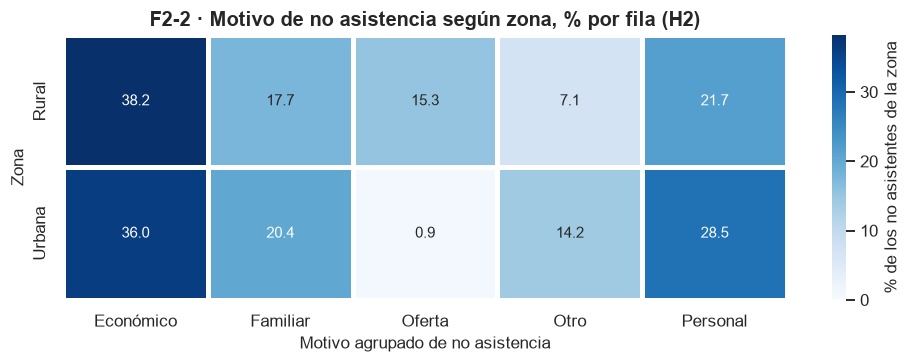

In [12]:
# F2-2 — Composición de motivos por zona (% de fila)
pct_h2 = tab_h2.div(tab_h2.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 3.4))
sns.heatmap(pct_h2, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=pct_h2.values.max(),
            linewidths=2, linecolor='white', cbar_kws={'label': '% de los no asistentes de la zona'}, ax=ax)
ax.set_xlabel('Motivo agrupado de no asistencia')
ax.set_ylabel('Zona')
ax.set_title('F2-2 · Motivo de no asistencia según zona, % por fila (H2)')
fig.tight_layout()
guardar(fig, 'F2_2_motivo_zona')

**Interpretación de F2-2.** En ambas zonas el motivo económico es el más frecuente (alrededor de 36–38 %). La diferencia
está en **Oferta** (no hay institución cercana, el centro cerró, etc.): 15.3 % de los no asistentes rurales frente a
0.9 % de los urbanos. En la ciudad pesan relativamente más “Otro” y “Personal”.

> **Lectura H2.** χ² ingenuo = 116.83 (gl = 4, p = 2.5·10⁻²⁴). El Wald con EE agrupado por UPM sigue rechazando
> (p ≈ 3·10⁻²⁰). V de Cramér = 0.247 (IC 95 % **bootstrap por UPM** [0.214, 0.288]), una asociación **débil a moderada**.
> Los residuos ajustados muestran qué celdas **contribuyen** más al estadístico: Oferta rural (+9.7) muy por encima de
> lo esperado bajo independencia, y “Otro” (−5.0) y “Personal” (−3.3) por debajo en lo rural. “Económico” (+0.9) y
> “Familiar” (−1.4) no se apartan de lo esperado. **Se rechaza la hipótesis nula** de H2: el motivo declarado se
> asocia con la zona, sobre todo por la falta de oferta educativa en el campo.


### H3 — Diferencias entre departamentos (χ² de homogeneidad + post hoc)

**Justificación de la prueba.** El desenlace es binario y hay **16 grupos** (departamentos). Comparar 16 proporciones
equivale a un χ² de homogeneidad sobre la tabla 16×2. No se usa ANOVA ni Kruskal–Wallis porque el desenlace no es
continuo ni ordinal con muchos valores. Como el χ² global solo dice que *algún* departamento difiere, se agrega un
**post hoc**: cada departamento contra Capital, con la diferencia de tasas y su EE **agrupado por UPM**, y
corrección BH sobre esas 15 comparaciones.

**Alcance.** La muestra cubre **15 departamentos más Asunción** (en el archivo, Asunción figura como Capital): 16
unidades en total. No están Boquerón ni Alto Paraguay. **Presidente Hayes sí está incluido.** La conclusión no se
extiende a Boquerón ni a Alto Paraguay.

**Supuestos (antes de la prueba):**


In [13]:
# H3 — Supuestos del χ² departamento × no_asiste
tab_h3 = pd.crosstab(df['departamento'], df['no_asiste'])
chi2_h3, p_h3, dof_h3, exp_h3 = stats.chi2_contingency(tab_h3, correction=False)
sup_h3 = chi2_supuestos(exp_h3)
print(f"Unidades geográficas en la muestra: {df.departamento.nunique()} "
      "(15 departamentos + Asunción). Fuera: Boquerón y Alto Paraguay.")
print("Presidente Hayes está en la muestra:", "Presidente Hayes" in set(df.departamento))
print(f"Mínimo esperado = {sup_h3['min_esperado']:.1f} · % celdas < 5 = {sup_h3['pct_celdas_menor_5']:.0f} % "
      f"→ supuesto de Cochran {'cumplido' if sup_h3['cumple'] else 'NO cumplido'}")


Unidades geográficas en la muestra: 16 (15 departamentos + Asunción). Fuera: Boquerón y Alto Paraguay.
Presidente Hayes está en la muestra: True
Mínimo esperado = 48.6 · % celdas < 5 = 0 % → supuesto de Cochran cumplido


In [14]:
# H3 — χ² global, V de Cramér con IC bootstrap y tabla completa por departamento
v_h3 = cramers_v(tab_h3)
v_h3_ci = bootstrap_cramers_v_cluster(df, 'departamento', 'no_asiste', 'upm_id', seed=SEMILLA)
w_h3, _, p_h3_upm = wald_cluster_asociacion(df, 'departamento', 'no_asiste', 'upm_id')
print(f'χ² ingenuo = {chi2_h3:.2f}   gl = {dof_h3}   p ingenuo = {fmt_p(p_h3)}')
print(f'Wald agrupado por UPM = {w_h3:.2f}   gl = {dof_h3}   p UPM = {fmt_p(p_h3_upm)}')
print(f'V de Cramér = {v_h3:.3f}   IC 95% bootstrap por UPM [{v_h3_ci[0]:.3f}, {v_h3_ci[1]:.3f}]')

dptos = df.groupby('departamento')['no_asiste'].agg(n='size', eventos='sum')
dptos['tasa %'] = 100 * dptos.eventos / dptos.n
lo, hi = proportion_confint(dptos.eventos, dptos.n, alpha=ALPHA, method='wilson')
dptos['IC95 inf %'], dptos['IC95 sup %'] = 100 * lo, 100 * hi
dptos = dptos.sort_values('tasa %', ascending=False)
display(dptos.round(1))


χ² ingenuo = 325.13   gl = 15   p ingenuo = 3.29e-60
Wald agrupado por UPM = 214.63   gl = 15   p UPM = 2.22e-37
V de Cramér = 0.116   IC 95% bootstrap por UPM [0.104, 0.139]


,n,eventos,tasa %,IC95 inf %,IC95 sup %
departamento,,,,,
Itapúa,2144,266,12.4,11.1,13.9
Guairá,969,111,11.5,9.6,13.6
Canindeyú,1367,144,10.5,9.0,12.3
Amambay,1138,118,10.4,8.7,12.3
San Pedro,1699,175,10.3,8.9,11.8
Caaguazú,1612,160,9.9,8.6,11.5
Alto Paraná,2886,272,9.4,8.4,10.5
Caazapá,1422,128,9.0,7.6,10.6
Presidente Hayes,902,73,8.1,6.5,10.1


In [15]:
# H3 — Post hoc: cada departamento contra Capital, con EE agrupado por UPM (familia BH de 15)
REF = 'Capital'
cap = df[df.departamento == REF]['no_asiste']
m_ph = smf.ols(
    "no_asiste ~ C(departamento, Treatment(reference='Capital'))",
    data=df,
).fit(cov_type='cluster', cov_kwds={'groups': df['upm_id']})
filas = []
for nombre, coef in m_ph.params.items():
    if nombre == 'Intercept':
        continue
    dpto = nombre.split('[T.')[-1].rstrip(']')
    ci = m_ph.conf_int().loc[nombre]
    tasa = df.loc[df.departamento == dpto, 'no_asiste'].mean()
    filas.append({
        'departamento': dpto,
        'prueba': 'Δ con EE agrupado por UPM',
        'tasa %': 100 * tasa,
        'Δ vs Capital (pp)': 100 * coef,
        'IC95 inf (pp)': 100 * ci[0],
        'IC95 sup (pp)': 100 * ci[1],
        'h de Cohen': cohen_h(tasa, cap.mean()),
        'p': m_ph.pvalues[nombre],
    })
posthoc_h3 = pd.DataFrame(filas)
rej, p_adj = benjamini_hochberg(posthoc_h3['p'].tolist(), alpha=ALPHA)
posthoc_h3['p BH'] = p_adj
posthoc_h3['difiere de Capital'] = np.where(rej, 'Sí', 'No')
posthoc_h3 = posthoc_h3.sort_values('Δ vs Capital (pp)', ascending=False).reset_index(drop=True)
print(f'Capital: tasa = {100 * cap.mean():.1f} %  (n = {len(cap):,}, eventos = {int(cap.sum())})')
display(posthoc_h3.style.format({'tasa %': '{:.1f}', 'Δ vs Capital (pp)': '{:.1f}', 'IC95 inf (pp)': '{:.1f}',
                                 'IC95 sup (pp)': '{:.1f}', 'h de Cohen': '{:.2f}', 'p': '{:.1e}',
                                 'p BH': '{:.1e}'}))
print(f"Difieren de Capital tras BH (p con UPM): {(posthoc_h3['difiere de Capital'] == 'Sí').sum()} de {len(posthoc_h3)}")
posthoc_h3.to_csv(DIR_TAB / 'fase2_posthoc_h3.csv', index=False, encoding='utf-8-sig')


Capital: tasa = 1.9 %  (n = 1,451, eventos = 28)


,departamento,prueba,tasa %,Δ vs Capital (pp),IC95 inf (pp),IC95 sup (pp),h de Cohen,p,p BH,difiere de Capital
0,Itapúa,Δ con EE agrupado por UPM,12.4,10.5,7.5,13.4,0.44,4.3e-12,2.1e-11,Sí
1,Guairá,Δ con EE agrupado por UPM,11.5,9.5,6.4,12.7,0.41,2.8e-09,8.4e-09,Sí
2,Canindeyú,Δ con EE agrupado por UPM,10.5,8.6,6.2,11.0,0.38,2.1e-12,1.6e-11,Sí
3,Amambay,Δ con EE agrupado por UPM,10.4,8.4,5.4,11.5,0.38,4.7e-08,1.2e-07,Sí
4,San Pedro,Δ con EE agrupado por UPM,10.3,8.4,4.9,11.9,0.37,2.5e-06,4.2e-06,Sí
5,Caaguazú,Δ con EE agrupado por UPM,9.9,8.0,5.0,11.0,0.36,2.1e-07,4.6e-07,Sí
6,Alto Paraná,Δ con EE agrupado por UPM,9.4,7.5,5.5,9.5,0.35,8.6e-14,1.3e-12,Sí
7,Caazapá,Δ con EE agrupado por UPM,9.0,7.1,4.7,9.4,0.33,2.7e-09,8.4e-09,Sí
8,Presidente Hayes,Δ con EE agrupado por UPM,8.1,6.2,3.5,8.8,0.30,4.3e-06,6.5e-06,Sí
9,Concepción,Δ con EE agrupado por UPM,7.9,6.0,3.5,8.4,0.29,1.6e-06,2.9e-06,Sí


Difieren de Capital tras BH (p con UPM): 15 de 15


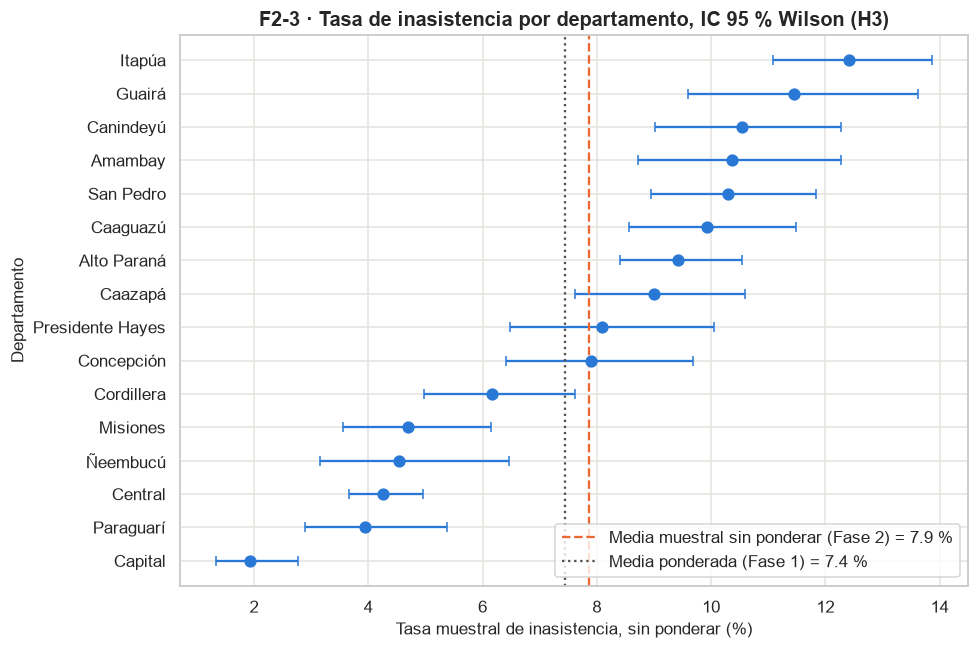

In [16]:
# F2-3 — Tasa por departamento con IC 95% de Wilson y las dos medias de referencia
d = dptos.sort_values('tasa %')
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(d))
ax.errorbar(d['tasa %'], y, xerr=[d['tasa %'] - d['IC95 inf %'], d['IC95 sup %'] - d['tasa %']],
            fmt='o', color=C_URB, ecolor=C_URB, elinewidth=1.5, capsize=3, markersize=7)
ax.axvline(TASA_NAC_SP, color=C_RUR, ls='--', lw=1.5,
           label=f'Media muestral sin ponderar (Fase 2) = {TASA_NAC_SP:.1f} %')
ax.axvline(TASA_NAC_P, color=C_GRIS, ls=':', lw=1.5,
           label=f'Media ponderada (Fase 1) = {TASA_NAC_P:.1f} %')
ax.set_yticks(y, d.index)
ax.set_xlabel('Tasa muestral de inasistencia, sin ponderar (%)')
ax.set_ylabel('Departamento')
ax.set_title('F2-3 · Tasa de inasistencia por departamento, IC 95 % Wilson (H3)')
ax.legend(loc='lower right', frameon=True)
fig.tight_layout()
guardar(fig, 'F2_3_tasa_departamento')

**Interpretación de F2-3.** Los departamentos forman un gradiente continuo: Capital (1.9 %) está muy por debajo de todos,
y en el otro extremo están Itapúa (12.4 %), Guairá (11.5 %), Canindeyú (10.5 %), Amambay (10.4 %) y San Pedro
(10.3 %). Los IC de los departamentos del centro se superponen entre sí, así que el ordenamiento fino no es robusto.
La línea naranja es la media muestral sin ponderar (7.9 %) y la punteada la ponderada de la Fase 1 (7.4 %).

> **Lectura H3.** χ² ingenuo = 325.13 (gl = 15, p = 3.3·10⁻⁶⁰). El Wald agrupado por UPM baja a ≈ 215
> (p ≈ 2·10⁻³⁷) y se sigue rechazando. V de Cramér = 0.116 (IC 95 % **bootstrap por UPM** [0.104, 0.139]), una
> asociación **débil** en términos globales. **Post hoc con EE por UPM:** los 15 departamentos (Presidente Hayes
> incluido) tienen una tasa mayor que Asunción/Capital tras BH. Las diferencias van de +2.0 pp (Paraguarí) a +10.5 pp
> (Itapúa). **Se rechaza la hipótesis nula** de H3. La relevancia práctica está en el abanico de 1.9 % a 12.4 %, no
> en el V global. El resultado no cubre Boquerón ni Alto Paraguay.


### H4 — Edad e inasistencia (ρ de Spearman)

**Justificación de la prueba.** La edad es **ordinal** (6 valores enteros, de 12 a 17) y el desenlace binario. No hay
normalidad que suponer, así que Pearson no es apropiado. Spearman mide asociación **monótona** con rangos y la H₁ es
direccional (ρ > 0). La significancia se evalúa con t = ρ·√((n−2)/(1−ρ²)), con gl = n − 2.

**Supuestos (antes de la prueba):**

In [17]:
# H4 — Supuestos de Spearman: escala ordinal, relación monótona, empates
por_edad = df.groupby('edad')['no_asiste'].agg(n='size', eventos='sum')
por_edad['tasa %'] = 100 * por_edad.eventos / por_edad.n
lo, hi = proportion_confint(por_edad.eventos, por_edad.n, alpha=ALPHA, method='wilson')
por_edad['IC95 inf %'], por_edad['IC95 sup %'] = 100 * lo, 100 * hi
display(por_edad.round(1))
print('Edad: entera 12–17 (ordinal) · no_asiste: binaria 0/1 (ordinal de dos niveles)')
print('¿Tasa monótona creciente con la edad?:', bool(por_edad['tasa %'].is_monotonic_increasing))
print('Empates: todos los valores se repiten; scipy usa rangos promedio (corrección estándar).')

,n,eventos,tasa %,IC95 inf %,IC95 sup %
edad,,,,,
12,4087,48,1.2,0.9,1.6
13,4208,114,2.7,2.3,3.2
14,4080,213,5.2,4.6,5.9
15,3940,304,7.7,6.9,8.6
16,4006,457,11.4,10.5,12.4
17,3995,776,19.4,18.2,20.7


Edad: entera 12–17 (ordinal) · no_asiste: binaria 0/1 (ordinal de dos niveles)
¿Tasa monótona creciente con la edad?: True
Empates: todos los valores se repiten; scipy usa rangos promedio (corrección estándar).


La tasa crece en cada año de edad sin excepción: la relación es monótona y Spearman es adecuado.

In [18]:
# H4 — ρ de Spearman con gl, IC 95% (Fisher, EE de Bonett–Wright) y sensibilidad por conglomerado
n_h4 = len(df)
rho_h4, p_h4_bil = stats.spearmanr(df['edad'], df['no_asiste'])
p_h4 = p_h4_bil / 2 if rho_h4 > 0 else 1 - p_h4_bil / 2     # Ha unilateral: ρ > 0
dof_h4 = n_h4 - 2
t_h4 = rho_h4 * np.sqrt(dof_h4 / (1 - rho_h4 ** 2))
ci_h4 = spearman_ci(rho_h4, n_h4)
print(f'ρ = {rho_h4:.4f}   t = {t_h4:.2f}   gl = {dof_h4:,}   p (unilateral) = {fmt_p(p_h4)}')
print(f'IC 95% de ρ: [{ci_h4[0]:.3f}, {ci_h4[1]:.3f}]')
# Sensibilidad: pendiente de rangos con EE agrupado por UPM
rk = pd.DataFrame({'re': df['edad'].rank(), 'rn': df['no_asiste'].rank(), 'g': df['upm_id']})
rk[['re', 'rn']] = (rk[['re', 'rn']] - rk[['re', 'rn']].mean()) / rk[['re', 'rn']].std()
m_rk = smf.ols('rn ~ re', data=rk).fit(cov_type='cluster', cov_kwds={'groups': rk['g']})
p_h4_upm = float(m_rk.pvalues['re'] / 2) if m_rk.params['re'] > 0 else float(1 - m_rk.pvalues['re'] / 2)
ci_h4_upm = (float(m_rk.conf_int().loc['re', 0]), float(m_rk.conf_int().loc['re', 1]))
print(f"EE agrupado por UPM: pendiente de rangos ≈ {m_rk.params['re']:.4f}, "
      f"IC 95% [{ci_h4_upm[0]:.3f}, {ci_h4_upm[1]:.3f}], "
      f"z = {m_rk.tvalues['re']:.1f}, p unilateral = {fmt_p(p_h4_upm)}")


ρ = 0.2166   t = 34.59   gl = 24,314   p (unilateral) = 2.71e-256
IC 95% de ρ: [0.204, 0.229]
EE agrupado por UPM: pendiente de rangos ≈ 0.2166, IC 95% [0.201, 0.232], z = 27.2, p unilateral = 1.24e-162


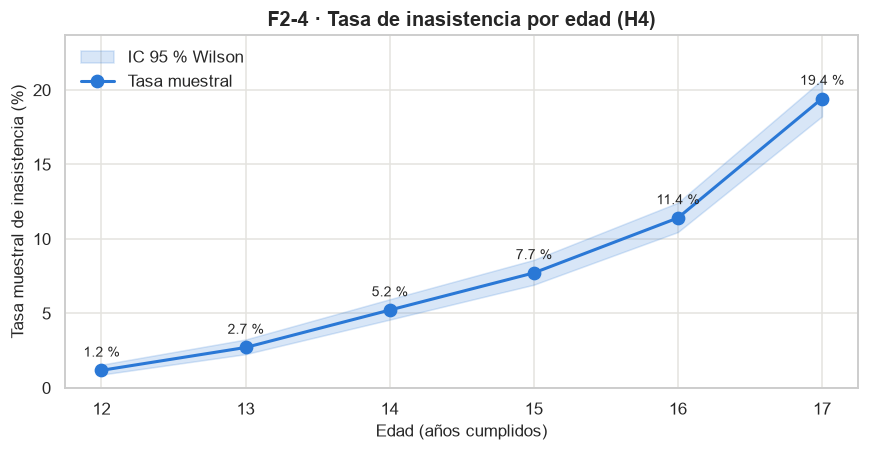

In [19]:
# F2-4 — Escalera de inasistencia por edad con banda IC 95%
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.fill_between(por_edad.index, por_edad['IC95 inf %'], por_edad['IC95 sup %'], color=C_URB, alpha=0.18,
                label='IC 95 % Wilson')
ax.plot(por_edad.index, por_edad['tasa %'], marker='o', markersize=8, lw=2, color=C_URB, label='Tasa muestral')
for e, v in por_edad['tasa %'].items():
    ax.annotate(f'{v:.1f} %', (e, v), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
ax.set_xlabel('Edad (años cumplidos)')
ax.set_ylabel('Tasa muestral de inasistencia (%)')
ax.set_ylim(0, por_edad['IC95 sup %'].max() + 3)
ax.set_title('F2-4 · Tasa de inasistencia por edad (H4)')
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
guardar(fig, 'F2_4_edad')

**Interpretación de F2-4.** La inasistencia sube en cada año de edad: **1.2 % a los 12 años → 19.4 % a los 17**, con
el salto más grande entre los 16 (11.4 %) y los 17. Los IC son angostos y no se superponen entre edades consecutivas.

> **Lectura H4.** ρ = 0.217 (IC 95 % de Fisher [0.204, 0.229]), t = 34.6, gl = 24.314, p ingenuo = 2.7·10⁻²⁵⁶.
> Con EE agrupado por UPM el IC de la pendiente de rangos es [0.201, 0.232] y el p unilateral sigue muy por debajo de
> 0.05. Como correlación, |ρ| ≈ 0.22 es **pequeño**. Aun así, la escalera de 1.2 % a 19.4 % tiene **gran relevancia
> práctica**. **Se rechaza la hipótesis nula** de H4: la inasistencia se asocia positivamente con la edad.


### H5 — Brecha rural ajustada por departamento, edad y sexo (regresión logística)

**Justificación de la prueba.** H1 compara zonas sin controlar nada, pero zona y departamento están relacionados: los
departamentos de mayor tasa son también más rurales. Esa es la principal **variable de confusión**. Para separar ambas
cosas se necesita un modelo con varios predictores. Como el desenlace es binario, corresponde una **regresión logística
múltiple**. Se contrasta el coeficiente de `rural` (prueba de Wald) y el modelo completo (razón de verosimilitud). El
departamento de referencia es Capital.

**Supuestos (antes de interpretar el modelo):**

In [20]:
# H5 — Supuestos de la regresión logística (antes de interpretar)
REF_DPTO = 'Capital'
FORMULA = f"no_asiste ~ rural + edad + mujer + C(departamento, Treatment(reference='{REF_DPTO}'))"
modelo = smf.logit(FORMULA, data=df).fit(disp=False)

# (a) Eventos por parámetro (regla EPV ≥ 10)
n_param = int(modelo.df_model)
epv = df.no_asiste.sum() / n_param
print(f'(a) Eventos = {int(df.no_asiste.sum()):,} · parámetros (sin intercepto) = {n_param} · EPV = {epv:.0f}  (≥ 10 ✔)')

# (b) Separación del modelo completo: eventos por departamento no alcanzan
ev_dpto = df.groupby('departamento')['no_asiste'].agg(['sum', 'size'])
ev_dpto['no_eventos'] = ev_dpto['size'] - ev_dpto['sum']
mu = modelo.predict()
print(f"(b) Convergencia MLE: {modelo.mle_retvals.get('converged')} en {modelo.mle_retvals.get('iterations')} iteraciones "
      f"(warnflag = {modelo.mle_retvals.get('warnflag')})")
print(f"    Probabilidad ajustada en [{mu.min():.4f}, {mu.max():.4f}] (no queda pegada en 0 ni en 1)")
print(f"    |coef| máximo = {modelo.params.abs().max():.2f} (es el intercepto: la edad no está centrada) · "
      f"EE máximo = {modelo.bse.max():.3f}")
print(f"    Eventos por departamento: mínimo {int(ev_dpto['sum'].min())} ({ev_dpto['sum'].idxmin()}); "
      f"no-eventos mínimo {int(ev_dpto['no_eventos'].min())}")
m_sin_rural = smf.logit(FORMULA.replace('rural + ', ''), data=df).fit(disp=False)
lr_rural = 2 * (modelo.llf - m_sin_rural.llf)
p_lr_rural = stats.chi2.sf(lr_rural, 1)
print(f"    LR de rural (1 gl) = {lr_rural:.1f}, p = {fmt_p(p_lr_rural)}; "
      f"Wald = {modelo.tvalues['rural']**2:.1f}, p = {fmt_p(modelo.pvalues['rural'])}. "
      f"Coinciden: no hay señal de Hauck–Donner.")

# (c) Multicolinealidad: VIF de cada columna de la matriz de diseño
X = pd.DataFrame(modelo.model.exog, columns=modelo.model.exog_names)
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns).drop('Intercept')
vif.index = [i.replace(f"C(departamento, Treatment(reference='{REF_DPTO}'))[T.", 'dpto: ').rstrip(']') for i in vif.index]
print(f"(c) VIF: rural = {vif['rural']:.2f} · edad = {vif['edad']:.2f} · mujer = {vif['mujer']:.2f} · "
      f"máximo dummies de dpto = {vif.filter(like='dpto').max():.2f}  (umbral habitual 5–10)")

# (d) Linealidad de la edad en el logit: LR edad lineal vs edad categórica
modelo_cat = smf.logit(FORMULA.replace('+ edad', '+ C(edad)'), data=df).fit(disp=False)
lr_lin = 2 * (modelo_cat.llf - modelo.llf)
gl_lin = int(modelo_cat.df_model - modelo.df_model)
p_lin = stats.chi2.sf(lr_lin, gl_lin)
logit_emp = np.log(por_edad.eventos / (por_edad.n - por_edad.eventos))
print(f'(d) LR edad lineal vs categórica: χ² = {lr_lin:.2f}, gl = {gl_lin}, p = {p_lin:.3f}')
print('    Logit empírico por edad y su salto anual:')
display(pd.DataFrame({'logit empírico': logit_emp, 'salto vs año anterior': logit_emp.diff()}).round(3).T)
print(f"    OR rural con edad lineal = {np.exp(modelo.params['rural']):.3f} · "
      f"con edad categórica = {np.exp(modelo_cat.params['rural']):.3f}")


(a) Eventos = 1,912 · parámetros (sin intercepto) = 18 · EPV = 106  (≥ 10 ✔)
(b) Convergencia MLE: True en 8 iteraciones (warnflag = 0)
    Probabilidad ajustada en [0.0028, 0.3996] (no queda pegada en 0 ni en 1)
    |coef| máximo = 12.27 (es el intercepto: la edad no está centrada) · EE máximo = 0.338
    Eventos por departamento: mínimo 28 (Capital); no-eventos mínimo 590
    LR de rural (1 gl) = 224.2, p = 1.10e-50; Wald = 213.3, p = 2.65e-48. Coinciden: no hay señal de Hauck–Donner.


(c) VIF: rural = 1.26 · edad = 1.00 · mujer = 1.00 · máximo dummies de dpto = 3.06  (umbral habitual 5–10)
(d) LR edad lineal vs categórica: χ² = 11.22, gl = 4, p = 0.024
    Logit empírico por edad y su salto anual:


edad,12,13,14,15,16,17
logit empírico,-4.433,-3.581,-2.899,-2.482,-2.050,-1.423
salto vs año anterior,NaN,0.851,0.682,0.417,0.432,0.627


    OR rural con edad lineal = 2.302 · con edad categórica = 2.300


- **(a) Eventos por parámetro:** EPV = 106, muy por encima de 10. Los coeficientes son estables.
- **(b) Convergencia y separación:** el MLE converge en 8 iteraciones. Las probabilidades ajustadas quedan entre
  0.003 y 0.40, sin pegarse a 0 o 1. El coeficiente más grande en valor absoluto es el intercepto (−12.3), porque la
  edad entra en años sin centrar, no porque una categoría esté separada. El LR y el Wald del coeficiente rural coinciden
  (≈ 224 y ≈ 213). Que cada departamento tenga casos positivos y negativos es necesario, pero no es el chequeo: el que
  se usa es convergencia, rango de las probabilidades ajustadas y acuerdo LR–Wald.
- **(c) Multicolinealidad:** VIF de rural = 1.26 y VIF máximo de las dummies = 3.06, por debajo de 5. La correlación
  entre zona y departamento no impide estimar ambos.
- **(d) Linealidad de la edad en el logit:** el LR entre edad lineal y edad categórica da χ² = 11.22, gl = 4,
  **p = 0.024**. La edad **no es perfectamente lineal** en el logit: los saltos anuales van de 0.42 a 0.85. Con n tan
  grande se detecta incluso una curvatura leve, y lo que importa para H5 es que **el OR rural no cambia** (2.302 con
  edad lineal y 2.300 con edad categórica). Se mantiene la edad lineal por parsimonia y se toma nota para la Fase 3.


In [21]:
# H5 — Resultados: test global (LR), Wald del coeficiente rural y odds ratios
print(f'Test global de razón de verosimilitud: LR χ² = {modelo.llr:.1f}, gl = {int(modelo.df_model)}, '
      f'p = {fmt_p(modelo.llr_pvalue)}')
print(f'Pseudo-R² de McFadden = {modelo.prsquared:.4f}')
z_h5 = modelo.tvalues['rural']
p_h5 = modelo.pvalues['rural']
print(f'Coeficiente rural: z = {z_h5:.3f} → Wald χ²(1) = {z_h5**2:.1f}, p = {fmt_p(p_h5)}')

ors = pd.DataFrame({'OR': np.exp(modelo.params), 'IC95 inf': np.exp(modelo.conf_int()[0]),
                    'IC95 sup': np.exp(modelo.conf_int()[1]), 'p': modelo.pvalues})
ors.index = [i.replace(f"C(departamento, Treatment(reference='{REF_DPTO}'))[T.", 'dpto: ').rstrip(']') for i in ors.index]
display(ors.drop('Intercept').style.format({'OR': '{:.3f}', 'IC95 inf': '{:.3f}', 'IC95 sup': '{:.3f}', 'p': '{:.1e}'}))
or_h5 = float(np.exp(modelo.params['rural']))
ci_h5 = tuple(np.exp(modelo.conf_int().loc['rural']))

Test global de razón de verosimilitud: LR χ² = 1862.4, gl = 18, p = < 1e-300
Pseudo-R² de McFadden = 0.1391
Coeficiente rural: z = 14.604 → Wald χ²(1) = 213.3, p = 2.65e-48


,OR,IC95 inf,IC95 sup,p
dpto: Alto Paraná,4.171,2.791,6.236,3.3e-12
dpto: Amambay,4.748,3.089,7.297,1.2e-12
dpto: Caaguazú,3.399,2.229,5.183,1.3e-08
dpto: Caazapá,2.534,1.643,3.907,2.6e-05
dpto: Canindeyú,3.970,2.594,6.075,2.1e-10
dpto: Central,1.927,1.277,2.908,1.8e-03
dpto: Concepción,2.706,1.723,4.250,1.6e-05
dpto: Cordillera,1.898,1.209,2.980,5.4e-03
dpto: Guairá,3.851,2.483,5.972,1.7e-09
dpto: Itapúa,4.573,3.039,6.881,3.0e-13


In [22]:
# H5 — Sensibilidad: (1) EE agrupados por UPM · (2) modelo ponderado por el factor de expansión
modelo_clu = smf.logit(FORMULA, data=df).fit(disp=False, cov_type='cluster',
                                              cov_kwds={'groups': df['upm_id']})
w = df['factor_expansion'] / df['factor_expansion'].mean()
with warnings.catch_warnings():
    # statsmodels avisa que cov_type 'no está totalmente soportado' con var_weights;
    # abajo se verifica a mano que el EE coincide con el sándwich de pseudo-verosimilitud.
    warnings.filterwarnings('ignore', message='cov_type not fully supported')
    modelo_w = smf.glm(FORMULA, data=df, family=sm.families.Binomial(), var_weights=w).fit(
        cov_type='cluster', cov_kwds={'groups': df['upm_id']})

# Verificación manual del EE agrupado del modelo ponderado (sándwich por conglomerado)
X_w, y_w, mu_w = modelo_w.model.exog, modelo_w.model.endog, modelo_w.fittedvalues.to_numpy()
pan = np.linalg.inv((X_w * (w.to_numpy() * mu_w * (1 - mu_w))[:, None]).T @ X_w)
S = pd.DataFrame(X_w * (w.to_numpy() * (y_w - mu_w))[:, None]).groupby(df['upm_id'].to_numpy()).sum().to_numpy()
G, (n_w, k_w) = S.shape[0], X_w.shape
V = pan @ (S.T @ S) @ pan * (G / (G - 1)) * ((n_w - 1) / (n_w - k_w))
i_r = modelo_w.model.exog_names.index('rural')
assert np.isclose(np.sqrt(V[i_r, i_r]), modelo_w.bse['rural']), 'El EE agrupado ponderado no coincide'

def fila_or(m, nombre):
    ci = np.exp(m.conf_int().loc['rural'])
    return {'especificación': nombre, 'OR rural': np.exp(m.params['rural']), 'EE (log-odds)': m.bse['rural'],
            'IC95 inf': ci[0], 'IC95 sup': ci[1], 'z': m.tvalues['rural'], 'p': m.pvalues['rural']}

sens_h5 = pd.DataFrame([fila_or(modelo, 'Principal: EE ingenuo, sin ponderar'),
                        fila_or(modelo_clu, 'EE agrupado por UPM, sin ponderar'),
                        fila_or(modelo_w, 'Ponderado (FEX) + EE agrupado por UPM')]).set_index('especificación')
display(sens_h5.style.format({'OR rural': '{:.3f}', 'EE (log-odds)': '{:.4f}', 'IC95 inf': '{:.3f}',
                              'IC95 sup': '{:.3f}', 'z': '{:.2f}', 'p': '{:.1e}'}))
print(f"Efecto de diseño del coeficiente rural (EE agrupado / EE ingenuo)² = "
      f"{(modelo_clu.bse['rural'] / modelo.bse['rural'])**2:.2f}")
ci_h5_clu = tuple(np.exp(modelo_clu.conf_int().loc['rural']))
p_h5_upm = float(modelo_clu.pvalues['rural'])


,OR rural,EE (log-odds),IC95 inf,IC95 sup,z,p
especificación,,,,,,
"Principal: EE ingenuo, sin ponderar",2.302,0.0571,2.059,2.575,14.60,2.6e-48
"EE agrupado por UPM, sin ponderar",2.302,0.0893,1.933,2.743,9.34,9.9e-21
Ponderado (FEX) + EE agrupado por UPM,2.226,0.0985,1.835,2.700,8.12,4.6e-16


Efecto de diseño del coeficiente rural (EE agrupado / EE ingenuo)² = 2.45


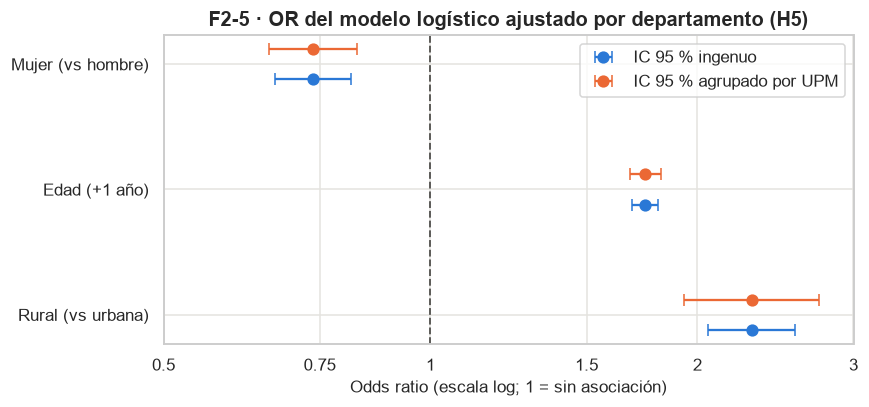

In [23]:
# F2-5 — Odds ratios de rural, edad y sexo: IC ingenuo vs IC agrupado por UPM
params = ['rural', 'edad', 'mujer']
etiquetas = ['Rural (vs urbana)', 'Edad (+1 año)', 'Mujer (vs hombre)']
fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(params))
for desp, m, col, lab in [(-0.12, modelo, C_URB, 'IC 95 % ingenuo'),
                          (0.12, modelo_clu, C_RUR, 'IC 95 % agrupado por UPM')]:
    o = np.exp(m.params[params]); ci = np.exp(m.conf_int().loc[params])
    ax.errorbar(o, y + desp, xerr=[o - ci[0], ci[1] - o], fmt='o', color=col, capsize=4,
                markersize=7, lw=1.5, label=lab)
ax.axvline(1, color=C_GRIS, ls='--', lw=1.2)
ax.set_xscale('log')
ax.set_xticks([0.5, 0.75, 1, 1.5, 2, 3], ['0.5', '0.75', '1', '1.5', '2', '3'])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_yticks(y, etiquetas)
ax.set_xlabel('Odds ratio (escala log; 1 = sin asociación)')
ax.set_title('F2-5 · OR del modelo logístico ajustado por departamento (H5)')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
guardar(fig, 'F2_5_or_logistica')

**Interpretación de F2-5.** Los tres OR están lejos de 1 (línea punteada): rural se asocia con más inasistencia
(OR ≈ 2.3), cada año de edad también (OR ≈ 1.75) y ser mujer con menos (OR ≈ 0.74). Los intervalos agrupados por UPM
(naranja) son más anchos que los ingenuos (azul), pero ninguno llega a cruzar el 1.

> **Lectura H5.** El modelo converge y es globalmente significativo (LR χ² = 1862.4, gl = 18, p < 10⁻³⁰⁰;
> pseudo-R² = 0.139). Controlando departamento, edad y sexo, el **OR rural = 2.30** (IC ingenuo [2.06, 2.58];
> Wald χ²(1) = 213.3, p = 2.6·10⁻⁴⁸). Con EE agrupado por UPM el IC pasa a [1.93, 2.74] y el p sigue ≈ 10⁻²⁰;
> ponderando por el FEX, OR = 2.23, IC [1.84, 2.70]. **Se rechaza la hipótesis nula** del coeficiente rural.
> Esto **no prueba causalidad**: es un corte transversal y faltan confusores potenciales como el ingreso del hogar, el
> trabajo adolescente y la distancia a la escuela.


### H6 — Mix de motivos 2025 vs 2022–2024 (χ² de independencia + residuos)

**Justificación de la prueba.** Período (2 niveles) y motivo (5 niveles) son **categóricos nominales**, así que
corresponde un χ² de independencia 2×5 sobre los no asistentes. Para saber **qué** motivos cambian, el χ² global no
alcanza: se analizan los **residuos estandarizados ajustados** de Haberman, que siguen una N(0,1) bajo H₀. Con 5 motivos
se aplica Bonferroni al umbral (|r| > 2.58).

**Supuestos (antes de la prueba):**

In [24]:
# H6 — Supuestos del χ² período × motivo
tab_h6 = pd.crosstab(noa['periodo'], noa['motivo_grupo'])
chi2_h6, p_h6, dof_h6, exp_h6 = stats.chi2_contingency(tab_h6, correction=False)
sup_h6 = chi2_supuestos(exp_h6)
display(tab_h6)
print(f"Mínimo esperado = {sup_h6['min_esperado']:.1f} · % celdas < 5 = {sup_h6['pct_celdas_menor_5']:.0f} % "
      f"→ supuesto de Cochran {'cumplido' if sup_h6['cumple'] else 'NO cumplido'}")

motivo_grupo,Económico,Familiar,Oferta,Otro,Personal
periodo,,,,,
2022-2024,586,277,169,126,346
2025,130,79,31,55,113


Mínimo esperado = 38.6 · % celdas < 5 = 0 % → supuesto de Cochran cumplido


El menor esperado es 38.6 (Otro en 2025) y ninguna celda tiene menos de 5: se cumple la regla de Cochran.

In [25]:
# H6 — χ², V de Cramér con IC bootstrap y residuos ajustados (¿qué motivos cambian?)
v_h6 = cramers_v(tab_h6)
v_h6_ci = bootstrap_cramers_v_cluster(noa, 'periodo', 'motivo_grupo', 'upm_id', seed=SEMILLA)
w_h6, _, p_h6_upm = wald_cluster_asociacion(noa, 'periodo', 'motivo_grupo', 'upm_id')
print(f'χ² ingenuo = {chi2_h6:.2f}   gl = {dof_h6}   p ingenuo = {fmt_p(p_h6)}')
print(f'Wald agrupado por UPM = {w_h6:.2f}   gl = {dof_h6}   p UPM = {fmt_p(p_h6_upm)}')
print(f'V de Cramér = {v_h6:.3f}   IC 95% bootstrap por UPM [{v_h6_ci[0]:.3f}, {v_h6_ci[1]:.3f}]')

pct_h6 = tab_h6.div(tab_h6.sum(axis=1), axis=0) * 100
res_h6 = residuos_ajustados(tab_h6)
Z_BONF = stats.norm.ppf(1 - ALPHA / (2 * tab_h6.shape[1]))   # 5 motivos → umbral corregido
pearson_h6 = (tab_h6 - exp_h6) / np.sqrt(exp_h6)      # residuo de Pearson: varianza < 1 bajo H0
resid_h6 = pd.DataFrame({'% 2022–2024': pct_h6.loc['2022-2024'], '% 2025': pct_h6.loc['2025'],
                         'cambio (pp)': pct_h6.loc['2025'] - pct_h6.loc['2022-2024'],
                         'residuo de Pearson 2025': pearson_h6.loc['2025'],
                         'residuo ajustado 2025': res_h6.loc['2025']})
resid_h6['|r| > 1.96'] = np.where(resid_h6['residuo ajustado 2025'].abs() > 1.96, 'Sí', 'No')
resid_h6[f'|r| > {Z_BONF:.2f} (Bonferroni)'] = np.where(resid_h6['residuo ajustado 2025'].abs() > Z_BONF, 'Sí', 'No')
display(resid_h6.round(2))
resid_h6.to_csv(DIR_TAB / 'fase2_residuos_h6.csv', encoding='utf-8-sig')


χ² ingenuo = 20.31   gl = 4   p ingenuo = 4.35e-04
Wald agrupado por UPM = 19.02   gl = 4   p UPM = 7.77e-04
V de Cramér = 0.103   IC 95% bootstrap por UPM [0.068, 0.152]


,% 2022–2024,% 2025,cambio (pp),residuo de Pearson 2025,residuo ajustado 2025,|r| > 1.96,|r| > 2.58 (Bonferroni)
motivo_grupo,,,,,,,
Económico,38.96,31.86,-7.10,-1.84,-2.63,Sí,Sí
Familiar,18.42,19.36,0.95,0.35,0.43,No,No
Oferta,11.24,7.60,-3.64,-1.79,-2.13,Sí,No
Otro,8.38,13.48,5.10,2.64,3.12,Sí,Sí
Personal,23.01,27.70,4.69,1.52,1.97,Sí,No


**Residuos de Pearson vs ajustados.** El residuo de Pearson (O−E)/√E tiene varianza **menor que 1** bajo H₀: su
varianza es (1 − proporción de fila)·(1 − proporción de columna). Por eso compararlo con ±1.96 es demasiado conservador.
El residuo ajustado corrige esa varianza y es el que se compara con la normal (Agresti, *Categorical Data Analysis*).
Con los residuos de Pearson, solo “Otro” (+2.64) supera 1.96, mientras que “Económico” (−1.84) y “Personal” (+1.52) no.
Con los residuos ajustados, que son los correctos para esta comparación, el panorama cambia.

In [26]:
# H6 — ¿Un cambio en la mezcla de zonas explica el cambio de motivos? (posible confusor)
print('% rural entre los no asistentes con motivo, por período:')
display((pd.crosstab(noa['periodo'], noa['zona'], normalize='index') * 100).round(1))
print('Mix de motivos por período DENTRO de cada zona (% fila):')
display((pd.crosstab([noa['zona'], noa['periodo']], noa['motivo_grupo'], normalize='index') * 100).round(1))

# Modelo log-lineal: periodo ⊥ motivo | zona. La combinación 2025–Urbana–Oferta tiene 0 casos;
# groupby().size() la descartaba. Se completa la grilla con ese cero y se recalcula.
cnt = noa.groupby(['periodo', 'zona', 'motivo_grupo']).size().reset_index(name='n')
grilla = pd.MultiIndex.from_product(
    [sorted(noa['periodo'].unique()), sorted(noa['zona'].unique()), sorted(noa['motivo_grupo'].unique())],
    names=['periodo', 'zona', 'motivo_grupo'])
cnt = cnt.set_index(['periodo', 'zona', 'motivo_grupo']).reindex(grilla, fill_value=0).reset_index()
cero = cnt[(cnt.periodo == '2025') & (cnt.zona == 'Urbana') & (cnt.motivo_grupo == 'Oferta')]
print(f"Celda incluida con cero casos: 2025–Urbana–Oferta, n = {int(cero['n'].iloc[0])} "
      f"(celdas en cero en la grilla: {int((cnt.n == 0).sum())})")
m0 = smf.glm('n ~ C(periodo)*C(zona) + C(motivo_grupo)*C(zona)', data=cnt, family=sm.families.Poisson()).fit()
m1 = smf.glm('n ~ C(periodo)*C(zona) + C(motivo_grupo)*C(zona) + C(periodo):C(motivo_grupo)',
             data=cnt, family=sm.families.Poisson()).fit()
print(f'Convergencia Poisson: m0={m0.converged}, m1={m1.converged}')
lr_cond = m0.deviance - m1.deviance
gl_cond = int(m1.df_model - m0.df_model)
p_cond = stats.chi2.sf(lr_cond, gl_cond)
print(f'LR condicional (periodo × motivo | zona): G² = {lr_cond:.2f}, gl = {gl_cond}, p = {p_cond:.2e}')


% rural entre los no asistentes con motivo, por período:


zona,Rural,Urbana
periodo,,
2022-2024,67.0,33.0
2025,64.5,35.5


Mix de motivos por período DENTRO de cada zona (% fila):


motivo_grupo      Económico  Familiar  Oferta  Otro  Personal
zona   periodo                                               
Rural  2022-2024       38.7      17.8    16.2   6.4      21.0
       2025            36.1      17.5    11.8   9.9      24.7
Urbana 2022-2024       39.4      19.7     1.2  12.5      27.2
       2025            24.1      22.8     0.0  20.0      33.1

Celda incluida con cero casos: 2025–Urbana–Oferta, n = 0 (celdas en cero en la grilla: 1)
Convergencia Poisson: m0=True, m1=True
LR condicional (periodo × motivo | zona): G² = 19.07, gl = 4, p = 7.63e-04


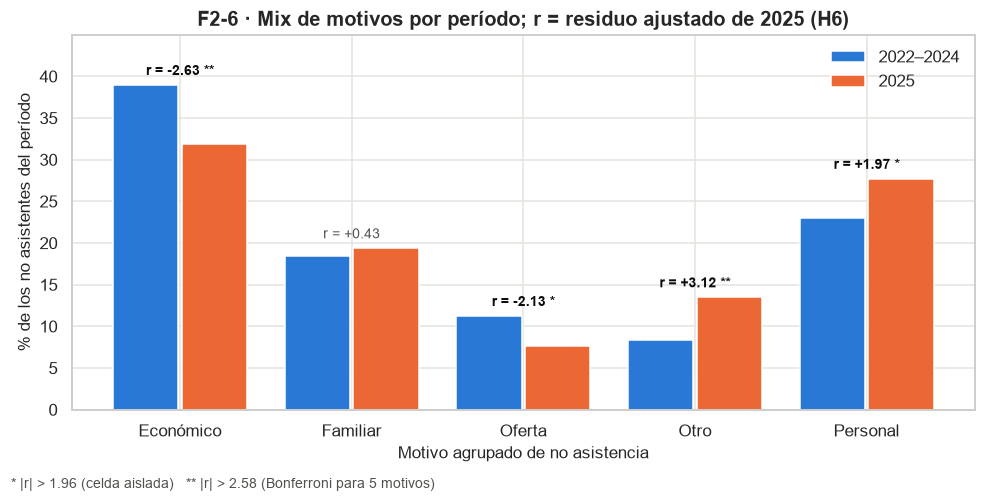

In [27]:
# F2-6 — Mix de motivos por período, con el residuo ajustado de 2025 anotado
fig, ax = plt.subplots(figsize=(9, 4.4))
motivos = pct_h6.columns
x = np.arange(len(motivos))
ax.bar(x - 0.2, pct_h6.loc['2022-2024'], width=0.38, color=C_URB, label='2022–2024')
ax.bar(x + 0.2, pct_h6.loc['2025'], width=0.38, color=C_RUR, label='2025')
for i, m in enumerate(motivos):
    r = res_h6.loc['2025', m]
    tope = pct_h6[m].max()
    marca = ' **' if abs(r) > Z_BONF else (' *' if abs(r) > 1.96 else '')
    ax.text(i, tope + 1.2, f'r = {r:+.2f}{marca}', ha='center', fontsize=9,
            color='#0b0b0b' if abs(r) > 1.96 else C_GRIS, fontweight='bold' if abs(r) > 1.96 else 'normal')
ax.set_xticks(x, motivos)
ax.set_xlabel('Motivo agrupado de no asistencia')
ax.set_ylabel('% de los no asistentes del período')
ax.set_ylim(0, pct_h6.values.max() + 6)
ax.set_title('F2-6 · Mix de motivos por período; r = residuo ajustado de 2025 (H6)')
ax.legend(frameon=False)
fig.text(0.01, -0.02, f'* |r| > 1.96 (celda aislada)   ** |r| > {Z_BONF:.2f} (Bonferroni para 5 motivos)',
         fontsize=9, color=C_GRIS)
fig.tight_layout()
guardar(fig, 'F2_6_motivo_periodo')

**Interpretación de F2-6.** En 2025 bajan Económico (39.0 % → 31.9 %) y Oferta (11.2 % → 7.6 %), y suben Otro
(8.4 % → 13.5 %) y Personal (23.0 % → 27.7 %). Solo los cambios marcados con ** superan el umbral de Bonferroni:
la **baja de Económico** (r = −2.63) y la **suba de Otro** (r = +3.12).

> **Lectura H6.** χ² ingenuo = 20.31 (gl = 4, p = 4.3·10⁻⁴); Wald por UPM p ≈ 7.8·10⁻⁴. V de Cramér = 0.103
> (IC 95 % bootstrap por UPM [0.068, 0.152]), una asociación **débil**. El mix de motivos de 2025 difiere del de
> 2022–2024. Por motivo:
> - **Sostenido con Bonferroni:** baja **Económico** (−7.1 pp, r = −2.63) y sube **Otro** (+5.1 pp, r = +3.12).
> - **No sostenido:** **Personal** (+4.7 pp, r = +1.97) y **Oferta** (−3.6 pp, r = −2.13) superan 1.96 como celdas
>   aisladas, pero no el umbral corregido de 2.58. Con 408 no asistentes en 2025, **no hay evidencia suficiente** para
>   afirmar que sube “no quiere estudiar”.
>
> **Confusor zona.** Si en 2025 hubiera menos no asistentes rurales, la caída de “Oferta” (motivo casi solo rural)
> podría deberse a la composición. La proporción rural apenas cambia (67.0 % → 64.5 %), y **dentro de la zona rural**
> Oferta también baja (16.2 % → 11.8 %). La celda **2025–Urbana–Oferta tiene 0 casos** y entra en el log-lineal con
> ese cero. Recalculado así, la asociación período–motivo **persiste condicionando en la zona** (G² ≈ 19.1, gl = 4,
> p ≈ 7.6·10⁻⁴). El Wald por UPM del χ² de H6 también rechaza (p ≈ 7.8·10⁻⁴).
> **Se rechaza la hipótesis nula** de H6. Relevancia práctica: hay que decir el año al citar “el” motivo principal.
> Como 2025 es un solo año, no puede afirmarse que sea una tendencia.


## 5. Tabla resumen y corrección por comparaciones múltiples

**Por qué corregir.** Cada prueba a α = 0.05 tiene 5 % de probabilidad de un falso positivo si H₀ es cierta. Con 5
pruebas independientes, la probabilidad de **al menos un** falso positivo llega a 1 − 0.95⁵ ≈ **22.6 %**. La corrección
mantiene bajo control el error del conjunto.

**Por qué Benjamini–Hochberg.** BH controla la **tasa de falsos descubrimientos** (FDR): entre las hipótesis que se
rechazan, se espera que a lo sumo una fracción α sean falsos positivos. Es menos conservador que Bonferroni, que
controla la probabilidad de *cualquier* falso positivo. Compartir la misma muestra **no garantiza** que las pruebas
estén correlacionadas en positivo, así que esa no es la justificación. Como comprobación, la misma familia se evalúa
también con Bonferroni. Si alguna decisión dependiera del método, se diría.

**Total declarado** (ver §1):
- **5** pruebas en la familia principal (H1, H2, H3, H4 y H6);
- **1** modelo de control (H5);
- **15** comparaciones post hoc de H3, con BH propia;
- **5** residuos de H6, con Bonferroni.

**Por qué H5 queda fuera de la familia.** H5 no es una pregunta nueva: vuelve a estimar la asociación rural de H1
ajustando por confusores. Igualmente se reporta qué pasa si se incluye en el BH. La decisión de cada fila usa el
**p con ajuste por UPM**, no el p que supone observaciones independientes.


In [28]:
# ============================================================================
# Tabla resumen de los seis contrastes (calculada aquí, no leída de disco)
# ============================================================================
filas = [
    {'H': 'H1', 'H0 → Ha': 'p_rural ≤ p_urbana → p_rural > p_urbana',
     'prueba': 'z de dos proporciones (unilateral)',
     'justificación': 'Desenlace binario, 2 grupos independientes, n grandes',
     'supuestos verificados': f'n·p y n·(1−p) ≥ 10 (mín. {int(sup_h1.drop(columns=["n", "cumple ≥ 10"]).values.min())}); '
                              f'bootstrap por UPM compatible con aprox. normal (Shapiro p = {sw_p:.2f})',
     'estadístico': f'z ingenuo = {z_h1:.2f}', 'gl': '— (z ~ N(0,1))',
     'p ingenuo': p_h1, 'p UPM': p_h1_upm,
     'IC 95 %': f'Wald [{ci_wald[0]:.4f}, {ci_wald[1]:.4f}]; UPM [{ci_h1_upm[0]:.4f}, {ci_h1_upm[1]:.4f}]; '
                f'bootstrap UPM [{boot_lo:.4f}, {boot_hi:.4f}]',
     'tamaño del efecto': f'h = {h_h1:.2f} (pequeño); Δp = {100*(p_r-p_u):.1f} pp; RR = {rr_h1:.2f}'},
    {'H': 'H2', 'H0 → Ha': 'zona ⊥ motivo → asociados',
     'prueba': 'χ² de independencia 2×5',
     'justificación': 'Dos variables categóricas nominales, tabla 2×5',
     'supuestos verificados': f"mín. esperado = {sup_h2['min_esperado']:.1f}; {sup_h2['pct_celdas_menor_5']:.0f} % celdas < 5; Wald por UPM",
     'estadístico': f'χ² = {chi2_h2:.2f}; Wald UPM = {w_h2:.1f}', 'gl': str(dof_h2),
     'p ingenuo': p_h2, 'p UPM': p_h2_upm,
     'IC 95 %': f'V bootstrap UPM [{v_h2_ci[0]:.3f}, {v_h2_ci[1]:.3f}]',
     'tamaño del efecto': f'V de Cramér = {v_h2:.3f}'},
    {'H': 'H3', 'H0 → Ha': 'tasa igual en las 16 unidades geográficas → al menos uno difiere',
     'prueba': 'χ² de homogeneidad 16×2 + post hoc vs Capital (BH)',
     'justificación': 'Desenlace binario, 15 departamentos + Asunción',
     'supuestos verificados': f"mín. esperado = {sup_h3['min_esperado']:.1f}; {sup_h3['pct_celdas_menor_5']:.0f} % celdas < 5; Wald y post hoc por UPM",
     'estadístico': f'χ² = {chi2_h3:.2f}; Wald UPM = {w_h3:.1f}', 'gl': str(dof_h3),
     'p ingenuo': p_h3, 'p UPM': p_h3_upm,
     'IC 95 %': f'V bootstrap UPM [{v_h3_ci[0]:.3f}, {v_h3_ci[1]:.3f}]',
     'tamaño del efecto': f'V de Cramér = {v_h3:.3f}'},
    {'H': 'H4', 'H0 → Ha': 'ρ ≤ 0 → ρ > 0',
     'prueba': 'ρ de Spearman (unilateral)',
     'justificación': 'Edad ordinal (6 valores) y desenlace binario: asociación monótona sin normalidad',
     'supuestos verificados': 'escala ordinal; tasa monótona creciente 12→17; empates con rangos promedio',
     'estadístico': f'ρ = {rho_h4:.3f} (t = {t_h4:.1f})', 'gl': f'{dof_h4:,}',
     'p ingenuo': p_h4, 'p UPM': p_h4_upm,
     'IC 95 %': f'Fisher [{ci_h4[0]:.3f}, {ci_h4[1]:.3f}]; UPM [{ci_h4_upm[0]:.3f}, {ci_h4_upm[1]:.3f}]',
     'tamaño del efecto': f'ρ = {rho_h4:.3f}; tasa {por_edad["tasa %"].iloc[0]:.1f} % → {por_edad["tasa %"].iloc[-1]:.1f} %'},
    {'H': 'H5', 'H0 → Ha': 'OR_rural = 1 → OR_rural ≠ 1 (ajustado)',
     'prueba': 'Regresión logística múltiple',
     'justificación': 'Desenlace binario y varios predictores: efecto de rural controlando dpto., edad y sexo',
     'supuestos verificados': f'EPV = {epv:.0f}; MLE convergido; μ en ({modelo.predict().min():.3f}, {modelo.predict().max():.2f}); '
                              f'LR rural ≈ Wald; VIF máx. = {vif.max():.1f}; linealidad edad LR p = {p_lin:.2f}',
     'estadístico': f'Wald χ² = {z_h5**2:.1f} (z = {z_h5:.2f}); LR global χ² = {modelo.llr:.0f}',
     'gl': f'1 (Wald rural); {int(modelo.df_model)} (LR global)',
     'p ingenuo': p_h5, 'p UPM': p_h5_upm,
     'IC 95 %': f'OR [{ci_h5[0]:.2f}, {ci_h5[1]:.2f}]; UPM [{ci_h5_clu[0]:.2f}, {ci_h5_clu[1]:.2f}]',
     'tamaño del efecto': f'OR = {or_h5:.2f}; pseudo-R² = {modelo.prsquared:.3f}'},
    {'H': 'H6', 'H0 → Ha': 'período ⊥ motivo → asociados',
     'prueba': 'χ² de independencia 2×5 + residuos ajustados',
     'justificación': 'Dos variables categóricas nominales, tabla 2×5',
     'supuestos verificados': f"mín. esperado = {sup_h6['min_esperado']:.1f}; {sup_h6['pct_celdas_menor_5']:.0f} % celdas < 5; "
                              f"cero 2025–Urbana–Oferta en el log-lineal; Wald por UPM",
     'estadístico': f'χ² = {chi2_h6:.2f}; Wald UPM = {w_h6:.1f}', 'gl': str(dof_h6),
     'p ingenuo': p_h6, 'p UPM': p_h6_upm,
     'IC 95 %': f'V bootstrap UPM [{v_h6_ci[0]:.3f}, {v_h6_ci[1]:.3f}]',
     'tamaño del efecto': f'V de Cramér = {v_h6:.3f}'},
]
resumen = pd.DataFrame(filas)

# BH y Bonferroni sobre los p ajustados por UPM de {H1, H2, H3, H4, H6}
FAMILIA = ['H1', 'H2', 'H3', 'H4', 'H6']
en_fam = resumen['H'].isin(FAMILIA)
rej, p_adj = benjamini_hochberg(resumen.loc[en_fam, 'p UPM'].tolist(), alpha=ALPHA)
resumen['p BH (UPM)'] = np.nan
resumen.loc[en_fam, 'p BH (UPM)'] = p_adj
rej_bon, p_bon, _, _ = multipletests(resumen.loc[en_fam, 'p UPM'].tolist(), alpha=ALPHA, method='bonferroni')
resumen['p Bonferroni (UPM)'] = np.nan
resumen.loc[en_fam, 'p Bonferroni (UPM)'] = p_bon
resumen['rechaza'] = False
resumen.loc[en_fam, 'rechaza'] = rej
resumen.loc[~en_fam, 'rechaza'] = resumen.loc[~en_fam, 'p UPM'] < ALPHA   # H5: p del EE agrupado
resumen['decisión'] = np.where(resumen['rechaza'], 'Se rechaza H0',
                               'No hay evidencia suficiente para rechazar H0')
print(f'Familia BH (p UPM): {int(en_fam.sum())} pruebas. '
      f'Bonferroni cambia alguna decisión de esa familia: {bool((rej_bon != rej).any())}')

rej6, p_adj6 = benjamini_hochberg(resumen['p UPM'].tolist(), alpha=ALPHA)
resumen['p BH (6, UPM)'] = p_adj6
print(f'¿BH sobre las 6 (con H5) cambia alguna decisión?: '
      f'{bool((rej6 != resumen["rechaza"].to_numpy()).any())}')

cols_mostrar = ['H', 'H0 → Ha', 'prueba', 'estadístico', 'gl', 'p ingenuo', 'p UPM', 'p BH (UPM)',
                'p Bonferroni (UPM)', 'IC 95 %', 'tamaño del efecto', 'decisión']
display(resumen[cols_mostrar].style.format(
    {'p ingenuo': '{:.2e}', 'p UPM': '{:.2e}', 'p BH (UPM)': '{:.2e}', 'p Bonferroni (UPM)': '{:.2e}'},
    na_rep='—').set_properties(**{'text-align': 'left', 'white-space': 'normal'}).hide(axis='index'))
resumen.drop(columns='rechaza').to_csv(DIR_TAB / 'fase2_resumen_contrastes.csv', index=False, encoding='utf-8-sig')
print('Guardado: output/tablas/fase2_resumen_contrastes.csv')


Familia BH (p UPM): 5 pruebas. Bonferroni cambia alguna decisión de esa familia: False
¿BH sobre las 6 (con H5) cambia alguna decisión?: False


H,H0 → Ha,prueba,estadístico,gl,p ingenuo,p UPM,p BH (UPM),p Bonferroni (UPM),IC 95 %,tamaño del efecto,decisión
H1,p_rural ≤ p_urbana → p_rural > p_urbana,z de dos proporciones (unilateral),z ingenuo = 18.45,"— (z ~ N(0,1))",2.76e-76,1.42e-25,2.36e-25,7.09e-25,"Wald [0.0569, 0.0708]; UPM [0.0518, 0.0759]; bootstrap UPM [0.0514, 0.0757]",h = 0.24 (pequeño); Δp = 6.4 pp; RR = 2.30,Se rechaza H0
H2,zona ⊥ motivo → asociados,χ² de independencia 2×5,χ² = 116.83; Wald UPM = 97.5,4,2.54e-24,3.35e-20,4.19e-20,1.68e-19,"V bootstrap UPM [0.214, 0.288]",V de Cramér = 0.247,Se rechaza H0
H3,tasa igual en las 16 unidades geográficas → al menos uno difiere,χ² de homogeneidad 16×2 + post hoc vs Capital (BH),χ² = 325.13; Wald UPM = 214.6,15,3.29e-60,2.22e-37,5.56e-37,1.11e-36,"V bootstrap UPM [0.104, 0.139]",V de Cramér = 0.116,Se rechaza H0
H4,ρ ≤ 0 → ρ > 0,ρ de Spearman (unilateral),ρ = 0.217 (t = 34.6),"24,314",2.71e-256,1.24e-162,6.19e-162,6.19e-162,"Fisher [0.204, 0.229]; UPM [0.201, 0.232]",ρ = 0.217; tasa 1.2 % → 19.4 %,Se rechaza H0
H5,OR_rural = 1 → OR_rural ≠ 1 (ajustado),Regresión logística múltiple,Wald χ² = 213.3 (z = 14.60); LR global χ² = 1862,1 (Wald rural); 18 (LR global),2.65e-48,9.95e-21,—,—,"OR [2.06, 2.58]; UPM [1.93, 2.74]",OR = 2.30; pseudo-R² = 0.139,Se rechaza H0
H6,período ⊥ motivo → asociados,χ² de independencia 2×5 + residuos ajustados,χ² = 20.31; Wald UPM = 19.0,4,4.35e-04,7.77e-04,7.77e-04,3.89e-03,"V bootstrap UPM [0.068, 0.152]",V de Cramér = 0.103,Se rechaza H0


Guardado: output/tablas/fase2_resumen_contrastes.csv


Con los p ajustados por UPM se rechazan las **hipótesis nulas** de H1, H2, H3, H4, H5 y H6, también tras BH y tras
Bonferroni en la familia principal. Si alguna no se hubiera rechazado, la conclusión sería *no hay evidencia suficiente
para rechazarla*, nunca que “se acepta”. La tabla queda en `output/tablas/fase2_resumen_contrastes.csv`.


## 6. Conclusión de la Fase 2

### Qué se sostuvo y qué no
- Se rechazan las **hipótesis nulas** correspondientes a H1, H2, H3, H4, H5 y H6. En H1–H4 y H6 la decisión usa el
  p con dependencia por UPM y sigue valiendo tras BH y tras Bonferroni. H5 usa el p del coeficiente rural con EE
  agrupado por UPM.
- En H6, el contraste global se sostiene, pero **solo la baja del motivo económico y la suba de “otro”** se sostienen
  individualmente. La suba de “no quiere estudiar” no supera la corrección.

### Implicancia para la pregunta de investigación
- **Zona:** la inasistencia rural (11.3 %) es 2.3 veces la urbana (4.9 %), y la brecha **persiste** al controlar
  departamento, edad y sexo (OR ≈ 2.3).
- **Departamento:** hay heterogeneidad, de 1.9 % en Capital a 12.4 % en Itapúa, aunque el efecto global es débil
  (V = 0.12).
- **Motivos:** dependen de la zona, sobre todo por la falta de oferta educativa en el campo, y su composición en 2025
  difiere de la de 2022–2024.
- **Edad:** se asocia positivamente con la inasistencia (1.2 % → 19.4 %).

Estas asociaciones confirman con evidencia inferencial el relato descriptivo de la Fase 1. **No son relaciones
causales.**

### Limitaciones de la inferencia
1. **Dependencia por conglomerados.** El efecto de diseño por UPM es ≈ 2.3 y los p que suponen independencia son
   optimistas. El ajuste por UPM (EE agrupado, Wald o bootstrap de conglomerados) se hizo en H1, H2, H3, H4, H5, H6 y
   en el post hoc departamental: en esos contrastes las hipótesis nulas se siguen rechazando. Eso no dice que
   “ningún resultado del notebook sea sensible al diseño”. El ajuste tampoco incorpora los estratos ni las réplicas
   oficiales de la DGEEC.
2. **Muestra, no población.** La inferencia es sobre n muestral sin ponderar (7.86 % nacional vs 7.44 % ponderado).
   El OR ponderado (2.23) es similar al no ponderado (2.30).
3. **Cobertura territorial.** Hay **15 departamentos más Asunción**. Faltan Boquerón y Alto Paraguay. Presidente Hayes
   sí está en la muestra. H3 y H5 no se extienden a los dos departamentos ausentes.
4. **Tamaño muestral.** Con n = 24.316, efectos pequeños resultan significativos; por eso se reporta siempre el tamaño
   del efecto. Con n = 408 no asistentes en 2025, H6 tiene poca potencia por motivo.
5. **Dependencia temporal.** Son cortes transversales repetidos, no un panel de personas. 2025 es un solo año.
6. **Medición.** El motivo es autorreportado y su agrupación es una decisión del grupo.
7. **Confusores no observados en H5:** ingreso del hogar, trabajo adolescente y distancia a la escuela.
8. **Especificación.** La edad no es perfectamente lineal en el logit (LR p = 0.024).

### Variables que pasan a la Fase 3
- **Target:** `no_asiste`, en una tarea de clasificación binaria desbalanceada (≈ 7.9 % positivos).
- **Predictores con respaldo inferencial:**
  - **edad** (H4 y H5; conviene modelarla de forma no lineal, por ejemplo categórica o con splines, según el LR de
    linealidad);
  - **zona** (H1 y H5);
  - **departamento** (H3 y H5);
  - **sexo** (H5, OR = 0.74).
- **Período:** H6 muestra que 2025 difiere, así que la partición debe ser **cronológica** (entrenar con 2022–2024 y
  probar con 2025) y hay que esperar cierto corrimiento de distribución.
- **Línea base:** clase mayoritaria (“todos asisten”) y una logística solo con zona.


## 7. Declaración de uso de IA

Se usó un asistente de IA como apoyo para:
- reorganizar el notebook;
- implementar la verificación de supuestos y las sensibilidades;
- revisar la redacción.

El grupo verificó cada estadístico contra las salidas de `scipy` y `statsmodels`, y las decisiones metodológicas son
del grupo, que puede defenderlas en la presentación. Esas decisiones son:
- qué pruebas usar;
- la familia BH;
- el tratamiento de la dependencia;
- la interpretación.